In [9]:
import pandas as pd
import numpy as np
import os
import pathlib
import sys
import json
base_path = pathlib.Path().resolve().parents[1]
PROJECT_ROOT = pathlib.Path("../").resolve()
sys.path.insert(0, str(PROJECT_ROOT))

import paths
from pybads import BADS
import pickle as pkl
import matplotlib.pyplot as plt
import seaborn as sns
from math_analysis.potencial import get_expressions
from helpers.sim_helpers_fit import simulate_path, make_drift
from helpers.sim_helpers_fit_numba import run_trial_numba

# Imports and summary of data

In [10]:
def strip_darken(ax):
    for collection in ax.collections:
        try:
            facecolors = collection.get_facecolors()
        except AttributeError:
            continue
        if len(facecolors) > 0:
            new_edgecolors = []
            for fc in facecolors:
                darkened = fc.copy()
                # Multiplicamos los valores RGB por 0.7 para oscurecer; ajustar si es necesario.
                darkened[:3] = darkened[:3] * 0.7
                new_edgecolors.append(darkened)
            collection.set_edgecolors(new_edgecolors)
            collection.set_linewidth(1.5)
    return

In [11]:
df = pd.read_csv(f'{paths.DATA_PATH}/df_filtered.csv', sep = ';')
df = df[df['timepoint_4'] < np.quantile(df['timepoint_4'], 0.95)]  #
# Count rows per subject
subject_counts = df['subject'].value_counts()
print("Number of rows per subject:")
print(subject_counts)
# Calculate percentage of rows with timepoint_4 > 5 for each subject
timepoint_high_pct = {}
for subject in df['subject'].unique():
    subject_df = df[df['subject'] == subject]
    high_timepoint = subject_df[subject_df['timepoint_4'] > 7.5].shape[0]
    total = subject_df.shape[0]
    timepoint_high_pct[subject] = (high_timepoint / total) * 100

# Convert to Series for better display
timepoint_high_series = pd.Series(timepoint_high_pct)
print("\nPercentage of rows with timepoint_4 > 7.5s by subject:")
print(timepoint_high_series)



print("\nSummary statistics:")
print(f"Total subjects: {len(subject_counts)}")
print(f"Average rows per subject: {subject_counts.mean():.2f}")
print(f"Minimum rows per subject: {subject_counts.min()}")
print(f"Maximum rows per subject: {subject_counts.max()}")

Number of rows per subject:
subject
A92    32658
A89    24057
A87    22278
A86    22029
A83    17435
A93    10867
A96    10109
A95     6495
A84      714
Name: count, dtype: int64

Percentage of rows with timepoint_4 > 7.5s by subject:
A83    0.0
A84    0.0
A86    0.0
A87    0.0
A89    0.0
A92    0.0
A93    0.0
A95    0.0
A96    0.0
dtype: float64

Summary statistics:
Total subjects: 9
Average rows per subject: 16293.56
Minimum rows per subject: 714
Maximum rows per subject: 32658


In [12]:
print(df['timepoint_1'].describe())
print(len(df[df['timepoint_1']<0]))
# df = df[df['timepoint_1'] > 0]  # Ensure timepoint_1 is positive
print(df['timepoint_2'].describe())
print(df['timepoint_3'].describe())
print(df['timepoint_4'].describe())

count    146642.000000
mean          0.627449
std           0.256268
min           0.013400
25%           0.462800
50%           0.573000
75%           0.719400
max           4.756200
Name: timepoint_1, dtype: float64
0
count    146642.000000
mean          1.032388
std           0.329001
min           0.216400
25%           0.812000
50%           0.967700
75%           1.167200
max           5.320400
Name: timepoint_2, dtype: float64
count    146642.000000
mean          1.404804
std           0.395648
min           0.328700
25%           1.138400
50%           1.330700
75%           1.575300
max           5.687200
Name: timepoint_3, dtype: float64
count    146642.000000
mean          3.318636
std           1.046818
min           0.844500
25%           2.555600
50%           3.068400
75%           3.856000
max           6.908400
Name: timepoint_4, dtype: float64


σ(V12) = 0.1427
σ(V34) = 0.9031


/var/folders/gk/r166p6nx2bb5zf2rlwww8fc00000gn/T/ipykernel_20401/1323397341.py:68: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/opt/homebrew/anaconda3/envs/pybads310/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/homebrew/anaconda3/envs/pybads310/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/homebrew/anaconda3/envs/pybads310/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8324 (\N{SUBSCRIPT FOUR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/homebrew/anaconda3/envs/pybads310/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8323 (\N{SUBSCRIPT TH

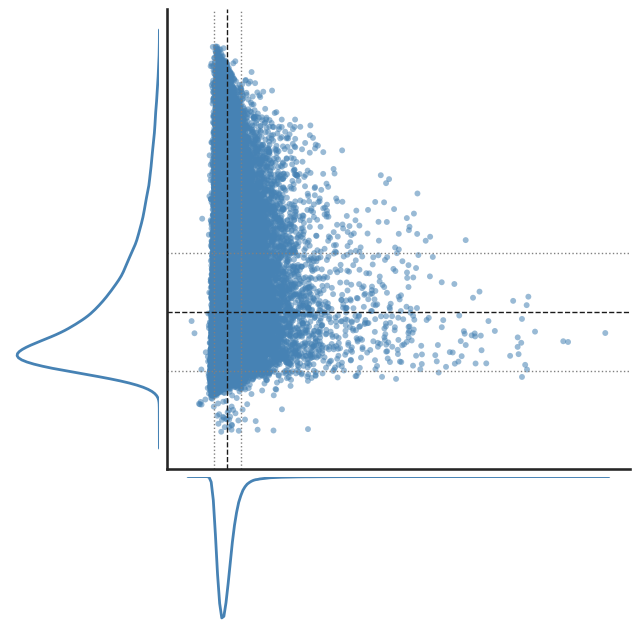

r = 0.1643, p-value = 0.0000e+00
Correlación Spearman: r = 0.2937, p-value = 0.0000e+00


In [13]:
from matplotlib.gridspec import GridSpec

# --- Calcular diferencias ---
df['V12'] = df['timepoint_2'] - df['timepoint_1']
df['V23'] = df['timepoint_3'] - df['timepoint_2']
df['V34'] = df['timepoint_4'] - df['timepoint_3']

# --- Asegurar datos numéricos y limpiar ---
df2 = df[['V12', 'V34']].copy()
df2['V12'] = pd.to_numeric(df2['V12'], errors='coerce')
df2['V34'] = pd.to_numeric(df2['V34'], errors='coerce')
df2 = df2.replace([np.inf, -np.inf], np.nan).dropna()

# --- Estadísticos ---
m_v12, m_v34 = df2['V12'].mean(), df2['V34'].mean()
sigma_v12, sigma_v34 = df2['V12'].std(ddof=1), df2['V34'].std(ddof=1)
print(f"σ(V12) = {sigma_v12:.4f}")
print(f"σ(V34) = {sigma_v34:.4f}")

# --- Layout base ---
sns.set(style="white", context="talk")
fig = plt.figure(figsize=(8, 8))
gs = GridSpec(4, 4, figure=fig, hspace=0.05, wspace=0.05)

ax_joint = fig.add_subplot(gs[0:3, 1:4])
ax_xmarg = fig.add_subplot(gs[3, 1:4], sharex=ax_joint)
ax_ymarg = fig.add_subplot(gs[0:3, 0], sharey=ax_joint)

# --- Scatter central ---
sns.scatterplot( data=df2, x='V12', y='V34', s=18, alpha=0.55, edgecolor='none', ax=ax_joint, color='steelblue')

# Líneas de media y ±σ
ax_joint.axvline(m_v12, ls='--', lw=1, color='k')
ax_joint.axhline(m_v34, ls='--', lw=1, color='k')
ax_joint.axvline(m_v12 + sigma_v12, ls=':', lw=1, color='gray')
ax_joint.axvline(m_v12 - sigma_v12, ls=':', lw=1, color='gray')
ax_joint.axhline(m_v34 + sigma_v34, ls=':', lw=1, color='gray')
ax_joint.axhline(m_v34 - sigma_v34, ls=':', lw=1, color='gray')

# --- Marginales solo KDE, pegadas e invertidas ---
sns.kdeplot(x=df2['V12'], ax=ax_xmarg, lw=2, color='steelblue', fill=False)
sns.kdeplot(y=df2['V34'], ax=ax_ymarg, lw=2, color='steelblue', fill=False)
ax_xmarg.invert_yaxis()
ax_ymarg.invert_xaxis()

# --- Estilo limpio sin ejes ni ticks externos ---
for ax in [ax_xmarg, ax_ymarg]:
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_xlabel(''); ax.set_ylabel('')
    sns.despine(ax=ax, left=True, bottom=True)

# Quitar números del joint excepto etiquetas
ax_joint.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

# --- Etiquetas principales ---
ax_joint.set_xlabel("V12 = t₂ - t₁", labelpad=10)
ax_joint.set_ylabel("V34 = t₄ - t₃", labelpad=10)
# --- Etiquetas principales (asegura que se vean) ---
ax_joint.set_xlabel("V12 = t₂ − t₁", labelpad=10)
ax_joint.set_ylabel("V34 = t₄ − t₃", labelpad=10)

# Si quieres ocultar solo los números (ticks) pero mantener las etiquetas de ejes:
ax_joint.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
ax_joint.xaxis.set_label_position('bottom')
ax_joint.yaxis.set_label_position('left')

sns.despine(ax=ax_joint)
plt.tight_layout()
plt.show()

from scipy.stats import pearsonr

r, pval = pearsonr(df2['V12'], df2['V34'])
print(f"r = {r:.4f}, p-value = {pval:.4e}")
from scipy.stats import spearmanr

r_s, p_s = spearmanr(df2['V12'], df2['V34'])
print(f"Correlación Spearman: r = {r_s:.4f}, p-value = {p_s:.4e}")

## Import Fitting results

In [14]:
import numpy as np
import pandas as pd
import os, json

param_names = [
    'sL','sC','sR','noise_amp','S_amplitude','S_d',
    'U_int_amplitude','U_int_baseline','U_ext_amplitude'
]

# ---------- utils ----------
def entropy_nats(p):
    p = np.asarray(p, dtype=float)
    p = p[(p > 0) & np.isfinite(p)]
    return float(-(p * np.log(p)).sum()) if p.size else 0.0

def H_conditional(df_subj, cond_cols=('stimd_c','ttype_c','x_c'), resp_col='r_c'):
    """H(C|S) con S = cond_cols (todas discretas); usa TODAS las filas de df_subj."""
    if df_subj.empty: return np.nan
    cols = list(cond_cols) + [resp_col]
    d = df_subj[cols].copy()
    for c in cols:
        d[c] = d[c].astype('string').str.strip()
    d = d[d[resp_col].isin({'L','C','R'})]
    if d.empty: return np.nan

    N = float(len(d))
    classes = ['L','C','R']
    H = 0.0
    for _, df_s in d.groupby(list(cond_cols)):
        n_s = float(len(df_s))
        counts = df_s[resp_col].value_counts()
        q = np.array([counts.get(c, 0)/n_s for c in classes], dtype=float)
        H += (n_s / N) * entropy_nats(q)
    return float(H)

def rel_vs_ceiling_from_values(nll_mean, H_cs, K=3):
    if not np.isfinite(nll_mean) or not np.isfinite(H_cs): return np.nan
    denom = np.log(K) - H_cs
    if denom <= 0: return np.nan
    val = 1.0 - ((nll_mean - H_cs) / denom)
    return float(np.clip(val, 0.0, 1.0))

def make_balanced_subset(df_subj, cond_cols=('stimd_c','ttype_c'), max_total=10000, seed=42):
    """Replica tu ‘balanceo simple por condición’ por sujeto (sin usar x_c)."""
    d = df_subj.copy()
    d['__cond__'] = d[cond_cols[0]].astype(str) + '_' + d[cond_cols[1]].astype(str)
    n_conds = d['__cond__'].nunique()
    if n_conds == 0: return d
    per_cond = max(1, max_total // n_conds)
    samples = []
    rng = np.random.RandomState(seed)
    for cond, dfc in d.groupby('__cond__'):
        n_sample = min(len(dfc), per_cond)
        samples.append(dfc.sample(n=n_sample, random_state=rng))
    out = pd.concat(samples, ignore_index=True)
    out.drop(columns='__cond__', inplace=True)
    return out

# ---------- leer resultados ----------
rows = []
subdir = os.path.join(paths.PARAMS_DIR, "spatialU_notrandom")
for filename in os.listdir(subdir):
    if filename.startswith("result_") and filename.endswith(".json") and "A92_3" not in filename:
        subject = filename.replace("result_", "").replace(".json", "")
        with open(os.path.join(subdir, filename), "r") as f:
            result_obj = json.load(f)

        x = result_obj["x"]
        row = {"subject": subject}
        for name, val in zip(param_names, x):
            row[name] = val

        row["nll"] = result_obj["fval"]
        row["nll/trial"] = (result_obj["fval"]/result_obj["n_trials"]
                            if result_obj.get("n_trials", 0) > 0 else np.nan)
        rows.append(row)
        print("U_int_base + U_int_ampl", subject, ":", x[6] + x[7])

params_df2 = pd.DataFrame(rows)

# ---------- cargar TODOS los datos del CSV (sin filtros) ----------
df_all = df.copy()
# ---------- diagnóstico y métrica ----------
K = 3
H_full_map = {}
for subj, dfg in df_all.groupby('subject'):
    # H con S completo (stimd_c, ttype_c, x_c) en TODO el dataset del sujeto
    H_full = H_conditional(dfg, cond_cols=('stimd_c','ttype_c','x_c'), resp_col='r_c')
    H_full_map[subj] = H_full

    # H en el subset balanceado que replicaba tu fit (cond = stimd_c + ttype_c)
    dfg_bal = make_balanced_subset(dfg, cond_cols=('stimd_c','ttype_c'), max_total=10000, seed=42)
    H_bal = H_conditional(dfg_bal, cond_cols=('stimd_c','ttype_c','x_c'), resp_col='r_c')

    print(f"[{subj}] H_full S=(stimd_c,ttype_c,x_c) = {H_full:.6f}  |  "
          f"H_balanced = {H_bal:.6f}")

def canonical_subject(s: str) -> str:
    """Devuelve la clave canónica del sujeto (prefijo antes de '_' o patrón letras+digitos)."""
    if s is None: return ''
    s = str(s).strip()
    if '_' in s:
        return s.split('_', 1)[0]
    m = re.match(r'^([A-Za-z]+[0-9]+)', s)
    return m.group(1) if m else s
params_df2['subject'] = params_df2['subject'].apply(canonical_subject)

# añadir SOLO la métrica normalizada usando H_full
params_df2['rel_vs_ceiling'] = params_df2.apply(
    lambda r: rel_vs_ceiling_from_values(r.get('nll/trial', np.nan),
                                         H_full_map.get(r['subject'], np.nan), K=K),
    axis=1
)

# chequeo coherencia
for _, r in params_df2.iterrows():
    subj = r['subject']
    nll_mean = r['nll/trial']
    H_full = H_full_map.get(subj, np.nan)
    if np.isfinite(nll_mean) and np.isfinite(H_full) and (nll_mean + 1e-9) < H_full:
        print(f"⚠️  NLL/trial ({nll_mean:.6f}) < H(C|S_full) ({H_full:.6f}) for {subj}. "
              f"Asegura que el NLL se evaluó en el mismo subset/condicionamiento.")

# mostrar y guardar
display(params_df2.sort_values('subject'))
params_df2.to_csv(f'{paths.PARAMS_DIR}/params_A89.csv', index=False)

U_int_base + U_int_ampl A83_spatial : -0.04561564630421344
U_int_base + U_int_ampl A84_spatial : 0.15525195747613907
U_int_base + U_int_ampl A96_spatial : 0.19252533197868615
U_int_base + U_int_ampl A89_spatial : 0.4569192766903143
U_int_base + U_int_ampl A86_spatial : -0.013176639478359675
U_int_base + U_int_ampl A93_spatial : 0.3137593502178788
U_int_base + U_int_ampl A92_spatial : 1.2827990354735235
U_int_base + U_int_ampl A95_spatial : 0.37996932830708374
U_int_base + U_int_ampl A87_spatial : 0.41934878625986016
[A83] H_full S=(stimd_c,ttype_c,x_c) = 0.721393  |  H_balanced = 0.703372
[A84] H_full S=(stimd_c,ttype_c,x_c) = 0.580821  |  H_balanced = 0.580821
[A86] H_full S=(stimd_c,ttype_c,x_c) = 0.726287  |  H_balanced = 0.695286
[A87] H_full S=(stimd_c,ttype_c,x_c) = 0.713937  |  H_balanced = 0.679603
[A89] H_full S=(stimd_c,ttype_c,x_c) = 0.732661  |  H_balanced = 0.714176
[A92] H_full S=(stimd_c,ttype_c,x_c) = 0.770973  |  H_balanced = 0.742003
[A93] H_full S=(stimd_c,ttype_c,x_

,subject,sL,sC,sR,noise_amp,S_amplitude,S_d,U_int_amplitude,U_int_baseline,U_ext_amplitude,nll,nll/trial,rel_vs_ceiling
0,A83,0.488374,0.501933,0.488729,1.084102,0.185933,3.456924e-01,0.944077,-0.989693,-0.095675,6973.421063,0.737850,0.956372
1,A84,0.453716,0.364545,0.505357,0.855582,0.237013,9.654027e-02,1.489218,-1.333966,-0.075844,400.909794,0.615837,0.932374
4,A86,0.123845,0.375873,0.282868,1.927568,0.375083,2.402712e-01,2.256323,-2.269500,0.467705,7312.693266,0.731562,0.985831
8,A87,0.264709,0.448689,0.310387,1.894914,0.408285,2.176751e-03,2.853288,-2.433939,0.440613,7368.213810,0.737116,0.939744
3,A89,0.329152,0.345985,0.354106,0.767177,0.160871,1.120454e-01,1.726481,-1.269562,-0.099998,7585.039366,0.758807,0.928553
6,A92,0.354093,0.472121,0.531550,1.565247,0.320768,4.390051e-08,3.579676,-2.296877,-0.100000,8058.402157,0.806163,0.892595
5,A93,0.343317,0.439884,0.375530,0.708036,0.158068,1.874241e-01,1.689054,-1.375295,-0.099838,5336.650307,0.720293,0.971322
7,A95,0.428427,0.528277,0.456462,0.902275,0.193956,1.967533e-01,2.027021,-1.647051,-0.099999,3980.137403,0.762478,0.901103
2,A96,0.282155,0.446050,0.352573,0.856250,0.188185,5.320604e-01,1.719552,-1.527026,-0.100000,4828.309361,0.701381,0.911192


In [22]:
param_names = [
    'sL', 'sC', 'sR', 'noise_amp', 'S_amplitude', 'S_d',
    'U_int_amplitude', 'U_int_baseline', 'U_int_onset', 'U_ext_amplitude'
]
param_names = [
    'sL', 'sC', 'sR', 'noise_amp', 'S_amplitude', 'S_d',
    'U_int_amplitude', 'U_int_baseline', 'U_ext_amplitude'
]

rows = []

for filename in os.listdir(paths.PARAMS_DIR):
    # if filename.startswith('result_') and not filename.endswith('ext_julia.pkl') and 'A92_3' not in filename and 'julia' not in filename:
    if filename.startswith('result_') and filename.endswith('ext_julia.pkl') and 'A92_3' not in filename :
        subject = filename.replace('result_', '').replace('.pkl', '')

        with open(os.path.join(paths.PARAMS_DIR, filename), 'rb') as f:
            result_obj = pkl.load(f)
        global_params = result_obj['x']
        row = {'subject': subject}
        for name, val in zip(param_names, global_params):
            row[name] = val
        row['nll'] = result_obj['fval']
        if "n_trials" in result_obj:
            row["nll/trial"] = result_obj["fval"] / result_obj["n_trials"]
        # row['nll/trial'] = result_obj['fval'] / result_obj['n_trials']
        rows.append(row)
        print('U_int_base + U_int_ampl', subject, ':', global_params[6] + global_params[7])

params_df = pd.DataFrame(rows)
params_df = params_df.sort_values(by='subject').reset_index(drop=True)
display(params_df)
params_df.to_csv(f'{paths.PARAMS_DIR}/params_df.csv', index=False)

rows = []

subdir = os.path.join(paths.PARAMS_DIR, "spatialU")

for filename in os.listdir(subdir):
    if filename.startswith("result_") and filename.endswith(".json") and "A92_3" not in filename:
        subject = filename.replace("result_", "").replace(".json", "")

        with open(os.path.join(subdir, filename), "r") as f:
            result_obj = json.load(f)

        global_params = result_obj["x"]
        row = {"subject": subject}
        for name, val in zip(param_names, global_params):
            row[name] = val
        row["nll"] = result_obj["fval"]
        if "n_trials" in result_obj:
            row["nll/trial"] = result_obj["fval"] / result_obj["n_trials"]
        rows.append(row)
        print("U_int_base + U_int_ampl", subject, ":", global_params[6] + global_params[7])
        
display(pd.DataFrame(rows))

params_df2 = pd.DataFrame(rows)
params_df2.to_csv(f'{paths.PARAMS_DIR}/params_A89.csv', index=False)
display(params_df2)





# a83 = [0.46782891, 0.47622047, 0.47975907, 0.43344636, 0.08423868, 0.83403804, 0.90973075, -0.86603898, 0.0994298 ]
# a86 =  [ 1.61316136e-01,  2.82051892e-01,  2.61488248e-01,  7.14031293e-01,  1.53146162e-01,  9.98825424e-01,  2.35324140e+00, -1.54241580e+00,  4.03727109e-05]
# a87 = [ 6.54471368e-01,  6.45592266e-01,  6.33354140e-01,  5.79894687e-01, 1.04438651e-01,  2.89207022e-01,  8.02697004e-01, -9.55936703e-01,  9.72445870e-05]
# a88 = [ 6.65900680e-01,  6.67237234e-01,  6.80509841e-01,  1.40146127e+00,  2.49846595e-01,  9.99819568e-01,  1.16811680e+00, -1.30533029e+00,  1.73671303e-07]
# a89 = [ 5.93288788e-01,  6.00104117e-01,  6.47263681e-01,  6.61103241e-01, 1.17213194e-01,  8.06228220e-01,  8.88418999e-01, -9.77977067e-01, 6.39746286e-04]
# a90 = [ 4.36104256e-01,  4.54154074e-01,  5.00710751e-01,  9.17268706e-01, 1.15753797e-01,  8.69694740e-01,  1.18714831e+00, -1.00466805e+00, 4.44952603e-05]
# a91 = [ 0.88495306,  0.93706201,  0.86545486,  1.59927088, 0.18755544,  0.90022335,  0.55584733, -0.95475157,  1.38607634]
# a92 = [ 2.96406879e-01,  3.23939485e-01,  3.30596091e-01,  4.04091597e-01, 7.60659767e-02,  5.84739973e-01,  8.89437591e-01, -7.35130646e-01, 7.10740386e-04]
# a93 = [ 0.19860581,  0.22185862,  0.19519365,  0.34053785,  0.05905547,  0.96439891,  0.68422257, -0.55145363,  0.00475499]
# a96 = [ 5.96291348e-01,  7.31257346e-01,  6.83685397e-01,  7.08671020e-01, 1.38535593e-01,  9.90784483e-01,  2.20695155e+00, -1.85181154e+00,7.02909140e-08]

# for subj, vals in zip(['A83', 'A86', 'A87', 'A88', 'A89', 'A90', 'A91', 'A92', 'A93', 'A96'], [a83, a86, a87, a88, a89, a90, a91, a92, a93, a96]):
#     row = {'subject': subj}
#     for name, val in zip(param_names, vals):
#         row[name] = val
#     rows.append(row)
#     print('U_int_base + U_int_ampl', subj, ':', vals[6] + vals[7])

# params_df = pd.DataFrame(rows)
# params_df = params_df.sort_values(by='subject').reset_index(drop=True)
# params_df.to_csv(f'{paths.PARAMS_DIR}/params_df.csv', index=False)

# print(f'{[x for x in params_df[params_df["subject"] == "A92_julia_ext_julia"].values[0][1:]]}, ')

U_int_base + U_int_ampl A92_julia_ext_julia : 0.6345267146313063
U_int_base + U_int_ampl A93_julia_ext_julia : 0.11368344910442829
U_int_base + U_int_ampl A89_julia_ext_julia : -0.13495134138744902
U_int_base + U_int_ampl A96_julia_ext_julia : 0.34306744409536805
U_int_base + U_int_ampl A95_julia_ext_julia : 0.954180783117863
U_int_base + U_int_ampl A83_julia_ext_julia : -0.10629883408546448
U_int_base + U_int_ampl A84_julia_ext_julia : 0.2065196713779045
U_int_base + U_int_ampl A87_julia_ext_julia : 0.1424206275951292
U_int_base + U_int_ampl A86_julia_ext_julia : 0.6289365673073917


,subject,sL,sC,sR,noise_amp,S_amplitude,S_d,U_int_amplitude,U_int_baseline,U_ext_amplitude,nll,nll/trial
0,A83_julia_ext_julia,0.508430,0.494158,0.498485,0.710225,0.114989,0.643321,0.690380,-0.796679,8.917331e-02,5530.439044,0.738475
1,A84_julia_ext_julia,0.402548,0.351841,0.424601,0.758967,0.150100,0.554290,0.863990,-0.657471,3.644254e-01,416.026877,0.639058
2,A86_julia_ext_julia,0.313336,0.446896,0.422735,1.087690,0.202037,0.197861,1.865245,-1.236308,1.165722e-04,5609.879495,0.748283
3,A87_julia_ext_julia,0.546528,0.598203,0.581504,0.642154,0.124134,0.303251,1.081730,-0.939309,5.833452e-02,5543.586787,0.739441
4,A89_julia_ext_julia,0.519279,0.519741,0.537677,0.438079,0.074538,0.523835,0.878549,-1.013501,3.199456e-01,5672.498620,0.756636
5,A92_julia_ext_julia,0.470809,0.515426,0.554880,0.837819,0.140530,0.309033,1.835905,-1.201378,5.316831e-02,6060.541982,0.808396
6,A93_julia_ext_julia,0.442970,0.497341,0.477417,0.503003,0.089331,0.312374,1.386028,-1.272345,7.450579e-11,4433.376293,0.741243
7,A95_julia_ext_julia,0.441566,0.494736,0.473940,0.695791,0.123097,0.986702,1.951871,-0.997691,2.636853e-01,3784.398451,0.763599
8,A96_julia_ext_julia,0.618589,0.751825,0.677569,0.695350,0.138952,0.999880,1.962129,-1.619062,8.859597e-05,3902.450112,0.715258


U_int_base + U_int_ampl A83_spatial : -1.8754690289497375
U_int_base + U_int_ampl A84_spatial : 1.7209529764457159
U_int_base + U_int_ampl A96_spatial : -4.999999731662683
U_int_base + U_int_ampl A89_spatial : -4.38761731427212
U_int_base + U_int_ampl A86_spatial : -2.6047719763300563
U_int_base + U_int_ampl A93_spatial : -1.9759507764064494
U_int_base + U_int_ampl A92_spatial : -1.8450992802018789
U_int_base + U_int_ampl A95_spatial : -1.3446306567639112
U_int_base + U_int_ampl A87_spatial : -1.581331729888916


,subject,sL,sC,sR,noise_amp,S_amplitude,S_d,U_int_amplitude,U_int_baseline,U_ext_amplitude,nll,nll/trial
0,A83_spatial,0.527607,0.732224,0.366059,1.897390,0.761338,0.763272,0.000000,-1.875469,2.155570,5775.509633,0.771199
1,A84_spatial,1.006651,0.552563,0.999104,1.847578,1.656269,0.824747,0.962688,0.758265,4.956906,479.183339,0.736073
2,A96_spatial,0.353132,1.386098,0.582365,1.999996,0.631339,0.023443,0.000000,-5.000000,4.776772,4162.628502,0.762945
3,A89_spatial,1.619375,1.897545,1.828266,1.990990,0.708456,0.531672,0.013895,-4.401512,3.644906,6008.738601,0.801486
4,A86_spatial,0.640832,1.447632,0.978477,1.999250,0.649113,0.999997,0.000195,-2.604967,2.203521,5887.378146,0.785298
5,A93_spatial,0.694003,1.356475,0.889015,2.000000,0.572799,0.657747,0.000012,-1.975962,1.470834,4671.833195,0.781112
6,A92_spatial,1.176778,1.411792,1.402132,1.605345,0.438752,0.685649,0.058387,-1.903486,1.197922,6305.839149,0.841115
7,A95_spatial,-0.061797,0.471946,-0.070280,1.971169,0.565826,0.762554,0.000000,-1.344631,1.662280,3993.637420,0.805819
8,A87_spatial,0.172367,0.598352,0.218333,1.999245,0.638132,0.300735,0.000000,-1.581332,1.684855,5865.511127,0.782381


,subject,sL,sC,sR,noise_amp,S_amplitude,S_d,U_int_amplitude,U_int_baseline,U_ext_amplitude,nll,nll/trial
0,A83_spatial,0.527607,0.732224,0.366059,1.897390,0.761338,0.763272,0.000000,-1.875469,2.155570,5775.509633,0.771199
1,A84_spatial,1.006651,0.552563,0.999104,1.847578,1.656269,0.824747,0.962688,0.758265,4.956906,479.183339,0.736073
2,A96_spatial,0.353132,1.386098,0.582365,1.999996,0.631339,0.023443,0.000000,-5.000000,4.776772,4162.628502,0.762945
3,A89_spatial,1.619375,1.897545,1.828266,1.990990,0.708456,0.531672,0.013895,-4.401512,3.644906,6008.738601,0.801486
4,A86_spatial,0.640832,1.447632,0.978477,1.999250,0.649113,0.999997,0.000195,-2.604967,2.203521,5887.378146,0.785298
5,A93_spatial,0.694003,1.356475,0.889015,2.000000,0.572799,0.657747,0.000012,-1.975962,1.470834,4671.833195,0.781112
6,A92_spatial,1.176778,1.411792,1.402132,1.605345,0.438752,0.685649,0.058387,-1.903486,1.197922,6305.839149,0.841115
7,A95_spatial,-0.061797,0.471946,-0.070280,1.971169,0.565826,0.762554,0.000000,-1.344631,1.662280,3993.637420,0.805819
8,A87_spatial,0.172367,0.598352,0.218333,1.999245,0.638132,0.300735,0.000000,-1.581332,1.684855,5865.511127,0.782381


# Fitting results analisys 

/var/folders/gk/r166p6nx2bb5zf2rlwww8fc00000gn/T/ipykernel_1161/1082931681.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_melted, x='parameter', y='value', palette='Set2', ax=ax)
/var/folders/gk/r166p6nx2bb5zf2rlwww8fc00000gn/T/ipykernel_1161/1082931681.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=df_melted, x='parameter', y='value', color='black', palette='Set2',alpha=0.5, jitter=True, ax=ax)


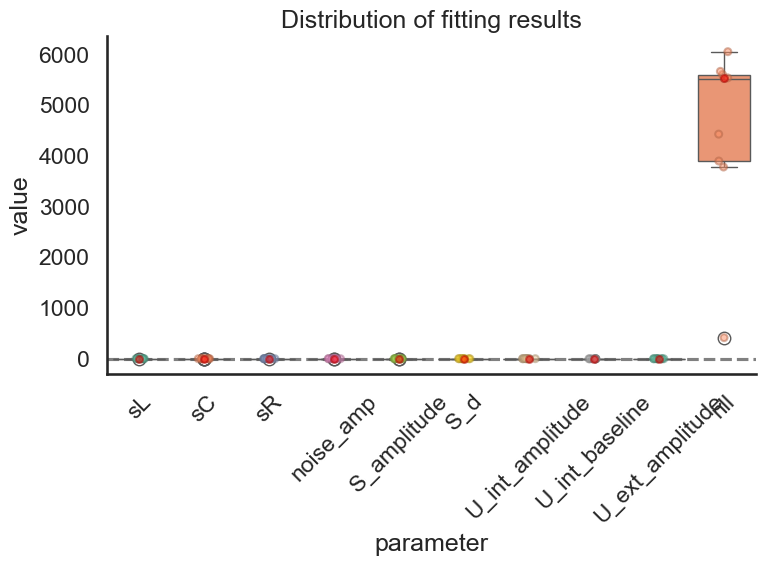

In [12]:
df_melted = params_df.melt(id_vars='subject', var_name='parameter', value_name='value')

# Boxplot
plt.figure(figsize=(8, 6))
ax = plt.gca()
ax.hlines(0, xmin=-0.5, xmax=len(df_melted['parameter'].unique())-0.5, color='gray', linestyle='--')
sns.boxplot(data=df_melted, x='parameter', y='value', palette='Set2', ax=ax)
sns.stripplot(data=df_melted, x='parameter', y='value', color='black', palette='Set2',alpha=0.5, jitter=True, ax=ax)
sns.stripplot(data=df_melted[df_melted['subject'].str.contains('A87')], x='parameter', y='value', color='red', alpha=0.5, jitter=True, ax=ax)
strip_darken(ax)
plt.title('Distribution of fitting results')
plt.xticks(rotation=45)

plt.grid(False)
plt.tight_layout()
sns.despine()
plt.show()

In [8]:
from statannotations.Annotator import Annotator
from scipy import stats
def stars(p):
    return '***' if p < 1e-3 else '**' if p < 1e-2 else '*' if p < 0.05 else 'ns'
labels = {'sL': f'$s_L$', 'sC': f'$s_C$', 'sR': f'$s_R$', 'noise_amp': f'$\sigma$', 'S_amplitude': r'$S^{amp}$', 'S_d': f'$S^d$', 'U_int_amplitude': r'$U_{int}^{amp}$', 'U_int_baseline': r'$U_{int}^{baseline}$',
          'U_int_onset': r'$U_{int}^{onset}$', 'U_ext_amplitude': r'$U_{ext}^{amp}$'}
order = list(labels.keys())

set2 = sns.color_palette("Set2", 8)
custom_palette = {'sL': set2[0],'sC': set2[1],'sR': set2[2],'U_int_amplitude': 
                  '#C38DFF', 'U_int_baseline':  '#C38DFF','U_int_onset':'#C38DFF',
                  'S_amplitude':'#FFA64C', 'S_d': '#FFA64C',
                  'U_ext_amplitude': '#3385FF',
                  'noise_amp':       '#999999', 'nll/trial': '#999999'}

params_df_subj = params_df.copy()
# params_df_subj = params_df[params_df['subject'].str.contains('A92')].copy()
params_df_subj.drop(columns=['nll'], inplace=True)
df_melted = params_df_subj.melt(id_vars='subject', var_name='parameter', value_name='value')

# Boxplot
plt.figure(figsize=(7, 5))
ax = sns.boxplot(data=df_melted, x='parameter', y='value', palette=custom_palette, hue = 'parameter')
sns.stripplot(data=df_melted, x='parameter', y='value', color='black', palette=custom_palette,alpha=0.5, jitter=True, ax = ax, hue = 'parameter')
sns.stripplot(data=df_melted[df_melted['subject'] == 'A92_2'], x='parameter', y='value', color='red',alpha=0.5, jitter=True, ax = ax)
strip_darken(ax)

params = ax.get_xticklabels()
xpos = np.arange(len(params))

x_centers = np.arange(len(order))
for subj in params_df_subj['subject'].unique():
    yvals = (df_melted[df_melted['subject'] == subj]
             .set_index('parameter')
             .reindex(order)['value'].values)
    if subj == 'A92_2':
        ax.plot(x_centers, yvals, linewidth=1.6, alpha=0.9, color='red', zorder=1)
    else:
        ax.plot(x_centers, yvals, linewidth=1.0, alpha=0.4, color='0.4', zorder=2)



t, pval = stats.ttest_1samp(df_melted[df_melted['parameter'] == 'U_ext_amplitude']['value'], 0.0)
ax.text(9, 0.2 + df_melted[df_melted['parameter'] == 'U_ext_amplitude']['value'].max(), stars(pval), ha='center', va='bottom', fontsize=13, color='black')

ax.axhline(0, linestyle='--', color = 'k')

new_labels = [labels.get(l.get_text(), l.get_text()) for l in ax.get_xticklabels()]
ax.set_xticklabels(new_labels)

plt.xticks()
plt.xlabel('Parameter')
plt.ylabel('Value')
plt.ylim(-2,2.5)
# plt.grid(True)
sns.set_style("ticks")
plt.tight_layout()
sns.despine()
plt.show()

NameError: name 'params_df' is not defined

['A83' 'A84' 'A96' 'A89' 'A86' 'A93' 'A92' 'A95' 'A87']


/var/folders/gk/r166p6nx2bb5zf2rlwww8fc00000gn/T/ipykernel_20401/879174209.py:50: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels, rotation=45)


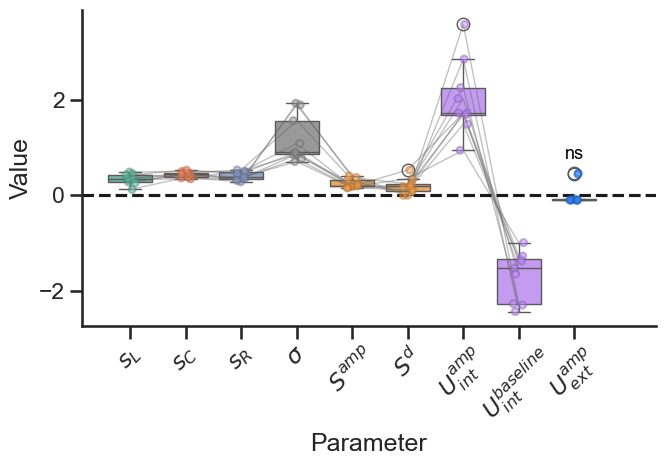

In [24]:
from statannotations.Annotator import Annotator
from scipy import stats
def stars(p):
    return '***' if p < 1e-3 else '**' if p < 1e-2 else '*' if p < 0.05 else 'ns'
order = list(labels.keys())

labels = {'sL': f'$s_L$', 'sC': f'$s_C$', 'sR': f'$s_R$', 'noise_amp': f'$\sigma$', 'S_amplitude': r'$S^{amp}$', 'S_d': f'$S^d$', 'U_int_amplitude': r'$U_{int}^{amp}$', 'U_int_baseline': r'$U_{int}^{baseline}$',
          'U_int_onset': r'$U_{int}^{onset}$', 'U_ext_amplitude': r'$U_{ext}^{amp}$'}
set2 = sns.color_palette("Set2", 8)
custom_palette = {'sL': set2[0],'sC': set2[1],'sR': set2[2],'U_int_amplitude': 
                  '#C38DFF', 'U_int_baseline':  '#C38DFF','U_int_onset':'#C38DFF',
                  'S_amplitude':'#FFA64C', 'S_d': '#FFA64C',
                  'U_ext_amplitude': '#3385FF',
                  'noise_amp':       '#999999', 'nll/trial': '#999999'}

params_df_subj = params_df2.copy()
# params_df_subj = params_df[params_df['subject'].str.contains('A92')].copy()
params_df_subj.drop(columns=['nll', 'nll/trial', 'rel_vs_ceiling'], inplace=True)
print(params_df2['subject'].unique())
df_melted = params_df_subj.melt(id_vars='subject', var_name='parameter', value_name='value')

# Boxplot
plt.figure(figsize=(7, 5))
ax = sns.boxplot(data=df_melted, x='parameter', y='value', palette=custom_palette, hue = 'parameter')
sns.stripplot(data=df_melted, x='parameter', y='value', color='black', palette=custom_palette,alpha=0.5, jitter=True, ax = ax,  hue = 'parameter')
sns.stripplot(data=df_melted[df_melted['subject'] == 'A92_2'], x='parameter', y='value', color='red',alpha=0.5, jitter=True, ax = ax)
strip_darken(ax)

params = ax.get_xticklabels()
xpos = np.arange(len(params))

x_centers = np.arange(len(order))
for subj in params_df_subj['subject'].unique():
    yvals = (df_melted[df_melted['subject'] == subj]
             .set_index('parameter')
             .reindex(order)['value'].values)
    if subj == 'A92_2':
        ax.plot(x_centers, yvals, linewidth=1.6, alpha=0.9, color='red', zorder=1)
    else:
        ax.plot(x_centers, yvals, linewidth=1.0, alpha=0.4, color='0.4', zorder=2)



t, pval = stats.ttest_1samp(df_melted[df_melted['parameter'] == 'U_ext_amplitude']['value'], 0.0)
ax.text(8, 0.2 + df_melted[df_melted['parameter'] == 'U_ext_amplitude']['value'].max(), stars(pval), ha='center', va='bottom', fontsize=13, color='black')

ax.axhline(0, linestyle='--', color = 'k')

new_labels = [labels.get(l.get_text(), l.get_text()) for l in ax.get_xticklabels()]
ax.set_xticklabels(new_labels, rotation=45)

plt.xticks()
plt.xlabel('Parameter')
plt.ylabel('Value')
# plt.grid(True)
sns.set_style("ticks")
# plt.ylim(-2,2.5)
plt.tight_layout()
sns.despine()
plt.show()

/var/folders/gk/r166p6nx2bb5zf2rlwww8fc00000gn/T/ipykernel_20401/2404300436.py:30: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(frameon=False, loc='upper right')


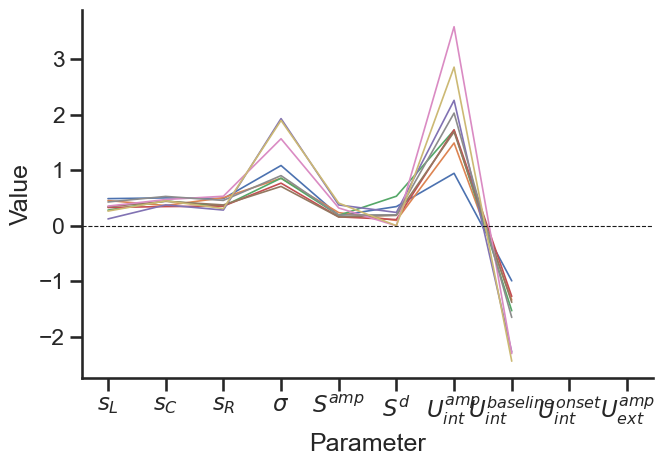

In [20]:

order = list(labels.keys())
x_centers = np.arange(len(order))

plt.figure(figsize=(7, 5))
ax = plt.gca()

for subj in params_df_subj['subject'].unique():
    yvals = (
        df_melted[df_melted['subject'] == subj]
        .set_index('parameter')
        .reindex(order)['value']
        .values
    )
    ax.plot(x_centers, yvals, linewidth=1.2, alpha=1, zorder=1)

# Línea horizontal de referencia
ax.axhline(0, linestyle='--', color='k', linewidth=0.8)

# Etiquetas del eje x (en notación LaTeX)
ax.set_xticks(x_centers)
ax.set_xticklabels([labels.get(k, k) for k in order], rotation=0)

# Estética general
plt.xlabel('Parameter')
plt.ylabel('Value')
sns.set_style("ticks")
# plt.ylim(-2, 2.5)
plt.tight_layout()
sns.despine()
plt.legend(frameon=False, loc='upper right')
plt.show()

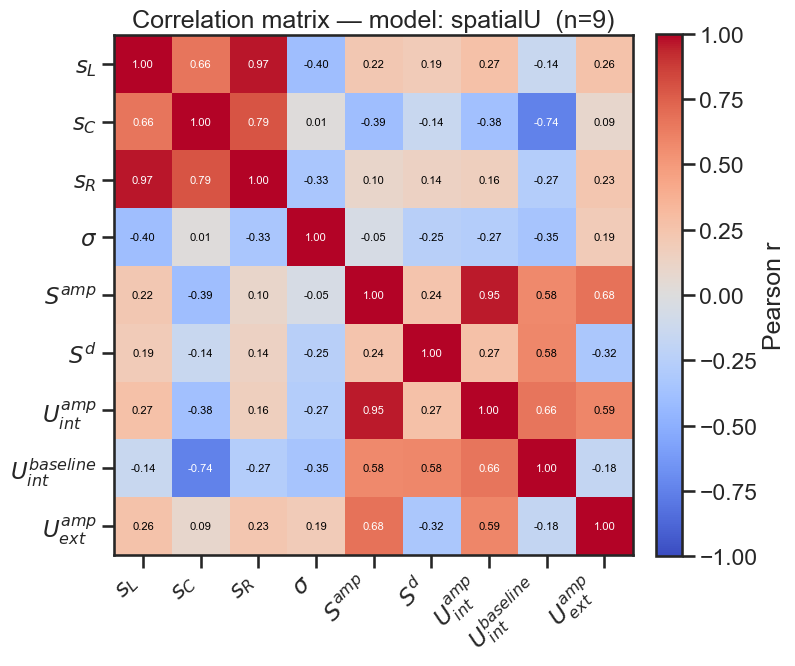

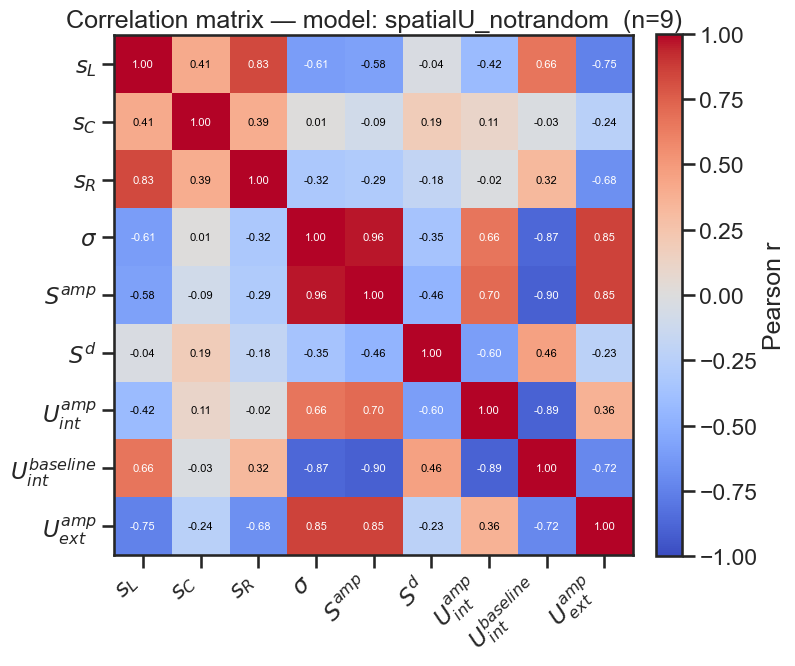

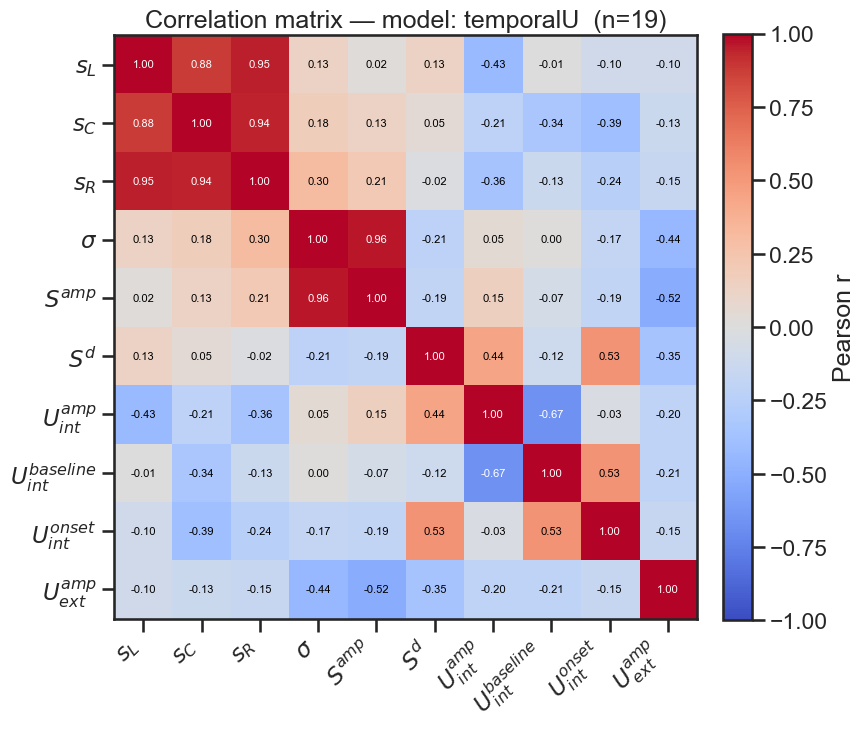

In [ ]:
for model, dfg in params_df2.groupby("model"):
    param_cols = param_names[model]
    corr_m = dfg[param_cols].corr(method='pearson')

    plt.figure(figsize=(0.7*len(param_cols)+2, 0.7*len(param_cols)+2))
    im = plt.imshow(corr_m, vmin=-1, vmax=1, cmap="coolwarm")
    plt.colorbar(im, fraction=0.046, pad=0.04, label="Pearson r")
    new_labels = [labels.get(l, l) for l in param_cols]
    
    plt.xticks(range(len(param_cols)), new_labels, rotation=45, ha='right')
    plt.yticks(range(len(param_cols)), new_labels)
    plt.title(f"Correlation matrix — model: {model}  (n={len(dfg)})")
    for i in range(len(param_cols)):
        for j in range(len(param_cols)):
            plt.text(j, i, f"{corr_m.iloc[i,j]:.2f}",
                     ha="center", va="center", fontsize=8,
                     color="black" if abs(corr_m.iloc[i,j])<0.6 else "white")
    plt.tight_layout()
    plt.show()

## Comparation of the fits

Detectados modelos: ['spatialU_notrandom', 'spatialU', 'temporalU']


/opt/homebrew/anaconda3/envs/pybads310/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


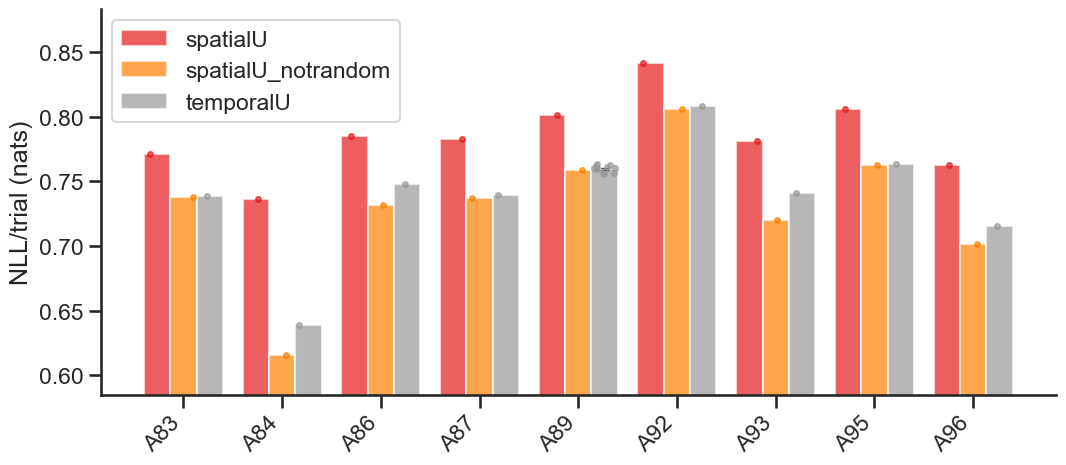

In [90]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os, json
import matplotlib.cm as cm

rows = []
subdirs = ['spatialU_notrandom', 'spatialU', 'temporalU']
subdirs = [os.path.join(paths.PARAMS_DIR, subdir) for subdir in subdirs]
param_names_temporal = [
    'sL', 'sC', 'sR', 'noise_amp', 'S_amplitude', 'S_d',
    'U_int_amplitude', 'U_int_baseline', 'U_int_onset', 'U_ext_amplitude'
]
param_names_spatial = [
    'sL', 'sC', 'sR', 'noise_amp', 'S_amplitude', 'S_d',
    'U_int_amplitude', 'U_int_baseline', 'U_ext_amplitude'
]
param_names = {'spatialU_notrandom': param_names_spatial, 'spatialU': param_names_spatial, 'temporalU': param_names_temporal}
print(f"Detectados modelos: {[os.path.basename(s) for s in subdirs]}")

rows = []

for subdir in subdirs:
    model_name = os.path.basename(subdir)
    for filename in os.listdir(subdir):
        if filename.endswith('.json') or filename.endswith('.pkl'):
            subject = filename.replace('result_', '')[:3]
            if filename.endswith('.pkl'):
                with open(os.path.join(subdir, filename), 'rb') as f:
                    result_obj = pkl.load(f)
            elif filename.endswith('.json'):
                with open(os.path.join(subdir, filename), "r") as f:
                    result_obj = json.load(f)

            x = result_obj["x"]
            row = {"subject": subject[:3], "model": model_name}
            for name, val in zip(param_names[model_name], x):
                row[name] = val

            row["nll"] = result_obj["fval"]
            row["n_trials"] = result_obj.get("n_trials", np.nan)
            row["nll/trial"] = (
                result_obj["fval"] / result_obj["n_trials"]
                if result_obj.get("n_trials", 0) > 0 else np.nan
            )
            rows.append(row)
        

params_df2 = pd.DataFrame(rows)
# ---------------- GROUPED BARPLOT: NLL/trial por subject y modelo ----------------
plt.figure(figsize=(11,5))

subjects = sorted(params_df2["subject"].unique())
models   = sorted(params_df2["model"].unique())
n_models = len(models)
width    = 0.8 / n_models                      # ancho de cada barra
xpos     = np.arange(len(subjects))            # posiciones base por subject

# resumen por celda: media y SEM
summary = (params_df2
           .groupby(["subject","model"], as_index=False)
           .agg(mean_nll=("nll/trial","mean"),
                sem_nll =("nll/trial", lambda v: np.nanstd(v, ddof=1)/np.sqrt(np.sum(np.isfinite(v))))))

# barras por modelo
for j, model in enumerate(models):
    xs = xpos + (j - (n_models-1)/2)*width
    sub = summary[summary["model"]==model].set_index("subject").reindex(subjects)
    means = sub["mean_nll"].values
    sems  = sub["sem_nll"].values

    plt.bar(xs, means, width=width, color=color_map[model], alpha=0.7, label=model)
    plt.errorbar(xs, means, yerr=sems, fmt="none", ecolor="k", elinewidth=1, capsize=3, alpha=0.8)

    # overlay de puntos individuales (todas las repeticiones)
    dfg = params_df2[params_df2.model==model]
    for i, s in enumerate(subjects):
        ys = dfg.loc[dfg.subject==s, "nll/trial"].values
        if ys.size == 0: 
            continue
        jitter = (np.random.rand(len(ys)) - 0.5)*width*0.8
        plt.plot(np.full_like(ys, xs[i]) + jitter, ys, "o", ms=4, alpha=0.7, color=color_map[model])


plt.xticks(xpos, subjects, rotation=45, ha="right")
plt.ylabel("NLL/trial (nats)")
plt.ylim(params_df2["nll/trial"].min()*0.95,
         params_df2["nll/trial"].max()*1.05)
plt.legend()
plt.tight_layout()
sns.despine()
plt.show()

### Correlation matrix

# Classical plots

## Helpers

In [ ]:
def get_onset_offset(stim_dur, delay_dur, timepoint_1, timepoint_2, timepoint_3, timepoint_4):
    """
    Devuelve los posibles valores de onset y el valor de offset
    según el tipo de trial.
    """
    if stim_dur == 'VG':
        onset = 0
        offset = timepoint_4

    elif stim_dur == 'SS':
        if delay_dur == 'DS':
            onset = timepoint_2
            offset = timepoint_3
        elif delay_dur == 'DM':
            onset = timepoint_1
            offset = timepoint_2
        elif delay_dur == 'DL':
            onset = 0
            offset = timepoint_1

    elif stim_dur == 'SM':
        if delay_dur == 'DS':
            onset = timepoint_1
            offset = timepoint_3
        elif delay_dur == 'DM':
            onset = 0
            offset = timepoint_2

    elif stim_dur == 'SL':
        onset = 0
        offset = timepoint_3
    
    elif stim_dur == 'SIL':
        onset = 0
        offset = 0

    else:
        raise ValueError(f"stim_dur desconocido: {stim_dur}")

    return onset, offset


In [ ]:
from collections import defaultdict

df[['onset', 'offset']] = df.apply(
    lambda row: pd.Series(get_onset_offset(
        row['stimd_c'], row['ttype_c'],
        row['timepoint_1'], row['timepoint_2'],
        row['timepoint_3'], row['timepoint_4']
    )),
    axis=1
)

## VG analysis

/var/folders/gk/r166p6nx2bb5zf2rlwww8fc00000gn/T/ipykernel_50640/1336278340.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = df_sil.groupby('t4_bin_fino')['correct_bool'].agg(['mean', 'count', 'std']).reset_index()


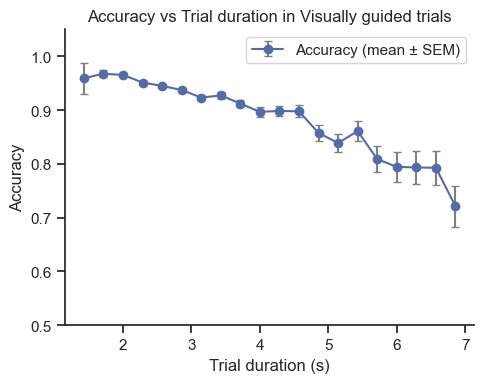

In [ ]:
# Filtramos solo SIL
df_sil = df[df['ttype_c'] == 'VG'].copy()

# Número de bins finos (ajusta a tu gusto)
n_bins_fino = 20

# Binning de t4
df_sil = df_sil[df_sil['timepoint_4']<=7]
df_sil['t4_bin_fino'] = pd.cut(df_sil['timepoint_4'], bins=n_bins_fino)
# Calculamos la media y el error estándar de la media (SEM) en cada bin
summary = df_sil.groupby('t4_bin_fino')['correct_bool'].agg(['mean', 'count', 'std']).reset_index()
summary['sem'] = summary['std'] / np.sqrt(summary['count'])

# Centro de cada bin para el eje X
summary['t4_bin_center'] = summary['t4_bin_fino'].apply(lambda x: x.mid)

plt.figure(figsize=(5,4))
plt.errorbar(summary['t4_bin_center'], summary['mean'], yerr=summary['sem'], 
             fmt='o-', color='#546bab', ecolor='gray', capsize=3, label='Accuracy (mean ± SEM)')
plt.xlabel('Trial duration (s)')
plt.ylabel('Accuracy')
plt.title(f'Accuracy vs Trial duration in Visually guided trials')
# plt.ylim(-0.05, 1.05)
plt.grid(False)
plt.ylim(0.5, 1.05)
plt.tight_layout()
plt.legend()
sns.despine()
plt.show()



## Delay balma plot

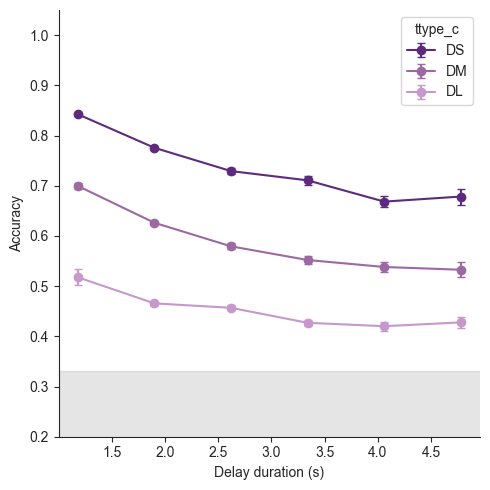

In [ ]:
# df['delay_duration'] = df['timepoint_4'] - df['offset']
df_nonsil = df[(df['ttype_c'] != 'SIL') & (df['ttype_c'] != 'VG')].copy()
df_nonsil = df_nonsil[df_nonsil['delay_abs'] >= 0].copy()
df_nonsil = df_nonsil[df_nonsil['delay_abs'] <= 5.5].copy()
n_bins = 6

low, high = df_nonsil['delay_abs'].quantile([0.01, 0.99])
delay_edges = np.linspace(low, high, n_bins+1)
delay_centers = 0.5 * (delay_edges[:-1] + delay_edges[1:])

ttype_colors = {'DS':'#5E2A7E', 'DM':"#9C69A3", 'DL':'#C698CB'}
plt.figure(figsize=(5,5))

for ttype, color in ttype_colors.items():
    dft = df_nonsil[df_nonsil['ttype_c'] == ttype].copy()
    dft['delay_bin'] = pd.cut(dft['delay_abs'], bins=delay_edges, include_lowest=True)

    means, sems = [], []
    for cat in dft['delay_bin'].cat.categories:
        bin_df = dft[dft['delay_bin'] == cat]
        n = len(bin_df)
        if n > 0:
            p = bin_df['accuracy'].mean()
            sem = np.sqrt(p*(1-p)/n)
        else:
            p, sem = np.nan, np.nan
        means.append(p)
        sems.append(sem)

    plt.errorbar(delay_centers, means, yerr=sems, fmt='o-', color=color,
                 capsize=3, label=ttype)

plt.axhspan(0, 0.33, 0,10, color='gray', alpha=0.2)
plt.xlabel('Delay duration (s)')
plt.ylabel('Accuracy')
plt.grid(False)
plt.legend(title='ttype_c')
plt.ylim(0.2, 1.05)
plt.tight_layout()
sns.despine()
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ===== Config =====
subject = 'A86'
n_bins = 8
M = 400
dt = 0.1/40
th = (0.0, 0.0, 0.0)
ttype_colors = {'DS':'#2980B9', 'DM':'#27AE60', 'DL':'#E67E22'}

from sim_core_numba import simulate_counts_one_trial_heun

row = params_df.loc[params_df['subject'] == f'{subject}'].iloc[0]
theta = dict(
    sL=float(row['sL']),
    sC=float(row['sC']),
    sR=float(row['sR']),
    noise=float(row['noise_amp']),
    S_amp=float(row['S_amplitude']),
    S_d=float(row['S_d']),
    U_amp=float(row['U_int_amplitude']),
    U_base=float(row['U_int_baseline']),
    U_on=float(row['U_int_onset']),
)

def get_onset_offset(stim_dur, delay_dur, t1, t2, t3, t4):
    if stim_dur == 'VG':
        return 0.0, t4
    elif stim_dur == 'SS':
        if delay_dur == 'DS': return t2, t3
        if delay_dur == 'DM': return t1, t2
        if delay_dur == 'DL': return 0.0, t1
    elif stim_dur == 'SM':
        if delay_dur == 'DS': return t1, t3
        if delay_dur == 'DM': return 0.0, t2
    elif stim_dur == 'SL':
        return 0.0, t3
    elif stim_dur == 'SIL':
        return 0.0, 0.0
    raise ValueError(f"stim/delay desconocidos: {stim_dur}/{delay_dur}")

def get_U_fn(amplitude, baseline, onset, offset):
    def U(t):
        t = np.asarray(t, dtype=np.float64)
        D = float(offset) - float(onset)
        u = np.full_like(t, float(baseline), dtype=np.float64)
        if D <= 0.0:
            return u  # ventana nula -> todo baseline
        active = (t >= onset) & (t <= onset + D)
        u[active] = baseline + amplitude * (t[active] - onset) / D
        return u
    return U


def get_S_fn(amplitude, d, onset, offset):
    def S(t):
        if onset - offset < 1e-5:
            return np.zeros_like(t, dtype=np.float64)
        S_base = np.where((t >= onset) & (t <= offset), amplitude, 0.0)
        tail = np.where((t > offset) & (t <= offset + d),
                        amplitude * (1.0 - (t - offset) / d), 0.0)
        return np.maximum(S_base, tail)
    return S

side_code_map = {'L':0, 'C':1, 'R':2}

def build_SU_for_trial(stimd, delayd, t1, t2, t3, t4, theta, dt):
    onset_S, offset_S = get_onset_offset(stimd, delayd, t1, t2, t3, t4)
    N = int(float(t4) / dt)
    if N <= 0:
        return None, None, 0
    t = np.linspace(0.0, float(t4), N, endpoint=False)
    S_t = get_S_fn(theta['S_amp'], theta['S_d'], onset_S, offset_S)(t).astype(np.float64, copy=False)
    U_t = get_U_fn(theta['U_amp'], theta['U_base'], theta['U_on'], float(t4))(t).astype(np.float64, copy=False)
    return np.ascontiguousarray(S_t), np.ascontiguousarray(U_t), N

# ===== Datos del sujeto (SOLO SS/SM) =====
df[['onset', 'offset']] = df.apply(
    lambda row: pd.Series(get_onset_offset(
        row['stimd_c'], row['ttype_c'],
        row['timepoint_1'], row['timepoint_2'],
        row['timepoint_3'], row['timepoint_4']
    )),
    axis=1
)
df['delay_duration'] = df['timepoint_4'] - df['offset']
df_nonsil = df[(df['ttype_c'] != 'SIL') & (df['ttype_c'] != 'VG')].copy()
df_nonsil = df_nonsil[df_nonsil['delay_duration'] <5].copy()
df_subj = df_nonsil[
    (df_nonsil['subject'] == subject)
].copy()

# --- Diagnóstico: comparamos delay_duration (datos) vs delay_model (modelo) ---
def delay_model_row(r):
    on, off = get_onset_offset(r['stimd_c'], r['ttype_c'],
                               r['timepoint_1'], r['timepoint_2'],
                               r['timepoint_3'], r['timepoint_4'])
    return float(off - on)

df_subj['delay_model'] = df_subj.apply(delay_model_row, axis=1)
corr = np.corrcoef(df_subj['delay_duration'].to_numpy(), df_subj['delay_model'].to_numpy())[0,1]
print(f"Corr(delay_duration, delay_model) = {corr:.3f}")
if corr < 0:
    print("⚠️ Ojo: delay_duration y delay_model van en sentido opuesto. Considera binnear por delay_model.")

# --- Elige variable de binning (usa la de datos, o cambia a 'delay_model' si quieres) ---
bin_var = 'delay_duration'  # o 'delay_model' si corr < 0 y quieres corregir
df_subj['delay_bin'], delay_edges = pd.qcut(df_subj[bin_var], n_bins, retbins=True, duplicates='drop')

# Centros de bin bien ORDENADOS
bin_stats = (
    df_subj.groupby('delay_bin', observed=True)[bin_var]
           .median()
           .rename('center')
           .reset_index()
)
# ordena por center ascendente
bin_stats = bin_stats.sort_values('center').reset_index(drop=True)
bin_order = list(bin_stats['delay_bin'])
delay_centers = bin_stats['center'].to_list()

plt.figure(figsize=(8, 5))

for ttype, color in ttype_colors.items():
    means_real, sems_real = [], []
    means_model, sems_model = [], []

    for cat in bin_order:  # usar SIEMPRE el ordenado
        bin_trials = df_subj[(df_subj['delay_bin'] == cat) & (df_subj['ttype_c'] == ttype)]
        n = len(bin_trials)
        if n == 0:
            means_real.append(np.nan); sems_real.append(np.nan)
            means_model.append(np.nan); sems_model.append(np.nan)
            continue

        # ---- REAL ----
        acc_real = bin_trials['correct_bool'].mean()
        sem_real = bin_trials['correct_bool'].std(ddof=1) / np.sqrt(n) if n > 1 else 0.0
        means_real.append(acc_real); sems_real.append(sem_real)

        # ---- MODELO ----
        # Subsample balanceado para no sesgar por lado
        SUBSAMPLE_PER_BIN = 480
        PER_SIDE_CAP = SUBSAMPLE_PER_BIN // 3
        if len(bin_trials) > SUBSAMPLE_PER_BIN:
            parts = []
            for side_label in ['L','C','R']:
                grp = bin_trials[bin_trials['x_c'] == side_label]
                parts.append(grp.sample(min(len(grp), PER_SIDE_CAP), random_state=0))
            bin_trials_iter = pd.concat(parts, axis=0)
            if len(bin_trials_iter) > SUBSAMPLE_PER_BIN:
                bin_trials_iter = bin_trials_iter.sample(SUBSAMPLE_PER_BIN, random_state=0)
        else:
            bin_trials_iter = bin_trials

        p_correct_trials = []
        for _, r in bin_trials_iter.iterrows():
            side_true = r['x_c']; side_code = side_code_map[side_true]
            S_t, U_t, N = build_SU_for_trial(
                r['stimd_c'], r['ttype_c'],
                float(r['timepoint_1']), float(r['timepoint_2']),
                float(r['timepoint_3']), float(r['timepoint_4']),
                theta, dt
            )
            if N <= 0: 
                continue
            mL, mC, mR = simulate_counts_one_trial_heun(
                S_t, U_t, side_code,
                theta['sL'], theta['sC'], theta['sR'],
                theta['noise'], dt, th[0], th[1], th[2], M
            )
            if side_true == 'L':
                p_correct_trials.append(mL / M)
            elif side_true == 'C':
                p_correct_trials.append(mC / M)
            else:
                p_correct_trials.append(mR / M)

        if len(p_correct_trials) == 0:
            means_model.append(np.nan); sems_model.append(np.nan)
        else:
            m = float(np.mean(p_correct_trials))
            s = float(np.std(p_correct_trials, ddof=1) / np.sqrt(len(p_correct_trials))) if len(p_correct_trials) > 1 else 0.0
            means_model.append(m); sems_model.append(s)

    # Plot
    plt.errorbar(delay_centers, means_real, yerr=sems_real,
                 fmt='o-', color=color, capsize=3, label=f'{ttype} (real)')
    plt.plot(delay_centers, means_model, '--o', color=color, alpha=0.85, label=f'{ttype} (modelo)')

# Add gray horizontal line and shaded area for chance level
plt.axhspan(0, 0.333, color='gray', alpha=0.1)
plt.xlabel(f'{bin_var} (s)')
plt.ylabel('Accuracy (p(correct))')
# plt.title(f'Accuracy vs {bin_var} — subject {subject}')
plt.legend(title='Delay type')
plt.ylim(0.2, 1.05)
sns.despine()
plt.tight_layout()
plt.show()

Corr(delay_duration, delay_model) = 0.022


KeyboardInterrupt: 

<Figure size 800x500 with 0 Axes>

## Average between subjects

In [ ]:
from tqdm import tqdm
n_bins = 8
M = 100
dt = 0.1/40
th = (0.5, 0.5, 0.5)
th = (0.0, 0.0, 0.0)
ttype_colors = {'DS':'#5E2A7E', 'DM':'#9C69A3', 'DL':'#C698CB'}

bin_var = 'delay_abs'   # o 'delay_model' si prefieres

# Solo SS/SM/SL (excluir SIL y VG) y corta delays extremos si quieres
df_nonsil = df[(df['ttype_c'] != 'SIL') & (df['ttype_c'] != 'VG')].copy()
df_nonsil = df_nonsil[df_nonsil['delay_abs'] < 5].copy()

# -------- Bins globales (idénticos para todos los sujetos) --------
# Usamos cuantiles globales del bin_var para qcut y luego aplicamos cut con edges
_, delay_edges = pd.qcut(df_nonsil[bin_var], n_bins, retbins=True, duplicates='drop')
df_nonsil['delay_bin'] = pd.cut(df_nonsil[bin_var], bins=delay_edges, include_lowest=True)

# Centros de bin globales (mediana global en cada bin)
bin_stats_global = (
    df_nonsil.groupby('delay_bin', observed=True)[bin_var]
             .median()
             .rename('center')
             .reset_index()
    .sort_values('center')
    .reset_index(drop=True)
)
bin_order = list(bin_stats_global['delay_bin'])
delay_centers = bin_stats_global['center'].to_list()

# ===== Lista de sujetos que tienen parámetros y datos =====
subjects_all = sorted(
    set(df_nonsil['subject'].unique()).intersection(set(params_df['subject'].unique()))
)

# === contenedores para promediar entre sujetos ===
per_subj_real = {tt: [[] for _ in bin_order] for tt in ttype_colors}
per_subj_model = {tt: [[] for _ in bin_order] for tt in ttype_colors}



for subject in tqdm(subjects_all):
    # --- parámetros del sujeto ---
    row = params_df.loc[params_df['subject'] == f'{subject}'].iloc[0]
    theta = dict(
        sL=float(row['sL']),
        sC=float(row['sC']),
        sR=float(row['sR']),
        noise=float(row['noise_amp']),
        S_amp=float(row['S_amplitude']),
        S_d=float(row['S_d']),
        U_amp=float(row['U_int_amplitude']),
        U_base=float(row['U_int_baseline']),
        U_on=float(row['U_int_onset']),
    )
    df_subj = df_nonsil[df_nonsil['subject'] == subject].copy()
    if df_subj.empty:
        continue

    for ttype in ttype_colors.keys():
        for bi, cat in enumerate(bin_order):
            bin_trials = df_subj[(df_subj['delay_bin'] == cat) & (df_subj['ttype_c'] == ttype)]
            n = len(bin_trials)
            if n == 0:
                # sujeto sin datos en este bin/ttype → saltamos (no añadimos nada)
                continue

            # ====== Datos (accuracy real del sujeto en ese bin/ttype) ======
            acc_real = bin_trials['correct_bool'].mean()
            per_subj_real[ttype][bi].append(float(acc_real))

            bin_trials_iter = bin_trials

            p_correct_trials = []
            for _, r in bin_trials_iter.iterrows():
                side_true = r['x_c']; side_code = side_code_map[side_true]
                S_t, U_t, N = build_SU_for_trial(
                    r['stimd_c'], r['ttype_c'],
                    float(r['timepoint_1']), float(r['timepoint_2']),
                    float(r['timepoint_3']), float(r['timepoint_4']),
                    theta, dt
                )
                if N <= 0:
                    continue
                mL, mC, mR = simulate_counts_one_trial_heun(
                    S_t, U_t, side_code,
                    theta['sL'], theta['sC'], theta['sR'],
                    theta['noise'], dt, th[0], th[1], th[2], M
                )
                if side_true == 'L':
                    p_correct_trials.append(mL / M)
                elif side_true == 'C':
                    p_correct_trials.append(mC / M)
                else:
                    p_correct_trials.append(mR / M)

            if len(p_correct_trials) > 0:
                per_subj_model[ttype][bi].append(float(np.mean(p_correct_trials)))

# ===== Agregación ENTRE sujetos: mean ± SEM por bin y ttype =====
def mean_sem(arr):
    arr = np.asarray(arr, dtype=float)
    arr = arr[~np.isnan(arr)]
    if arr.size == 0:
        return np.nan, np.nan
    if arr.size == 1:
        return float(arr[0]), 0.0
    return float(np.mean(arr)), float(np.std(arr, ddof=1)/np.sqrt(arr.size))



  0%|          | 0/6 [00:00<?, ?it/s]

Simulando sujeto A83 con params: {'sL': 0.5012122043408453, 'sC': 0.454482666333206, 'sR': 0.4680242525646463, 'noise': 0.9388505584810423, 'S_amp': 0.1523275710688904, 'S_d': 0.5771109260153026, 'U_amp': 0.9044465837068856, 'U_base': -0.8690148970345035, 'U_on': 0.13732343249069529}


  0%|          | 0/6 [00:02<?, ?it/s]


KeyboardInterrupt: 

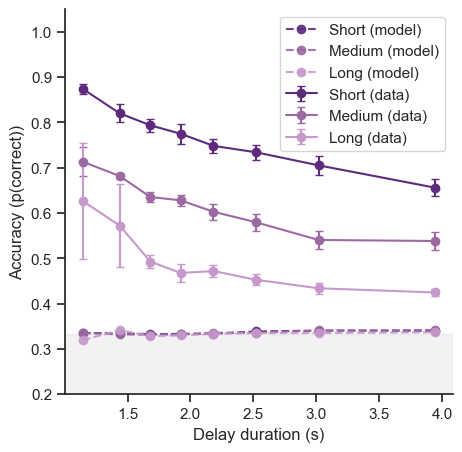

In [ ]:
plt.figure(figsize=(5, 5))

ttype_name = {'DS':'Short', 'DM':'Medium', 'DL':'Long'}

for ttype, color in ttype_colors.items():
    means_real, sems_real = [], []
    means_model, sems_model = [], []
    for bi in range(len(bin_order)):
        m_r, s_r = mean_sem(per_subj_real[ttype][bi])
        m_m, s_m = mean_sem(per_subj_model[ttype][bi])
        means_real.append(m_r); sems_real.append(s_r)
        means_model.append(m_m); sems_model.append(s_m)

    plt.errorbar(delay_centers, means_real, yerr=sems_real,
                 fmt='o-', color=color, capsize=3, label=f'{ttype_name[ttype]} (data)')
    plt.plot(delay_centers, means_model, '--o', color=color, alpha=0.9,
             label=f'{ttype_name[ttype]} (model)')

# ===== Estética =====
plt.axhspan(0, 0.333, color='gray', alpha=0.1)
plt.xlabel(f'Delay duration (s)')
plt.ylabel('Accuracy (p(correct))')
plt.ylim(0.2, 1.05)
plt.legend(title='')
sns.despine()
sns.set()
sns.set_style('white')
sns.set_style('ticks')

plt.show()

# Comparison classical plots

### Helpers

In [ ]:
from juliacall import Main as jl

jl.seval(r"""
import Pkg
Pkg.activate(@__DIR__); Pkg.instantiate()
using Random
using .SimNLL

function simulate_counts_one_trial_heun(
    S_t::Vector{Float64},
    U_t::Vector{Float64},
    side::Integer,
    sL::Float64, sC::Float64, sR::Float64,
    noise_amp::Float64,
    dt::Float64,
    th1::Float64, th2::Float64, th3::Float64,
    M::Int;
    seed::UInt64 = 0x12345678
)::NTuple{3,Int}
    @assert length(S_t) == length(U_t)
    N = length(S_t)
    Z0 = Vector{Float64}(undef, N)
    Z1 = Vector{Float64}(undef, N)
    Z2 = Vector{Float64}(undef, N)

    srt = sqrt(dt)
    s1_coef = noise_amp * (srt * 0.5)
    s2_coef = noise_amp * (srt / 6.0)

    rng = Xoshiro(seed)

    mL = 0; mC = 0; mR = 0
    for j in 1:M
        randn!(rng, Z0)
        randn!(rng, Z1)
        randn!(rng, Z2)

        k = if Int(side) == 0
            SimNLL._heun_sideL!(S_t, U_t, N, sL, sC, sR, s1_coef, s2_coef, dt, th1, th2, th3, Z0, Z1, Z2)
        elseif Int(side) == 1
            SimNLL._heun_sideC!(S_t, U_t, N, sL, sC, sR, s1_coef, s2_coef, dt, th1, th2, th3, Z0, Z1, Z2)
        else
            SimNLL._heun_sideR!(S_t, U_t, N, sL, sC, sR, s1_coef, s2_coef, dt, th1, th2, th3, Z0, Z1, Z2)
        end

        if     k == 0; mL += 1
        elseif k == 1; mC += 1
        elseif k == 2; mR += 1
        end
    end
    return (mL, mC, mR)
end
""")



def simulate_counts_one_trial_heun_jl(S_t, U_t, code, theta, dt, th_tuple, M, seed=12345678):
    th1, th2, th3 = th_tuple
    mL, mC, mR = jl.simulate_counts_one_trial_heun(
        S_t, U_t, int(code),
        float(theta['sL']), float(theta['sC']), float(theta['sR']),
        float(theta['noise']), float(dt),
        float(th1), float(th2), float(th3), int(M),
        seed=np.uint64(seed)
    )
    return int(mL), int(mC), int(mR)

[juliapkg] Found dependencies: /opt/homebrew/anaconda3/envs/pybads310/lib/python3.10/site-packages/juliapkg/juliapkg.json
[juliapkg] Found dependencies: /opt/homebrew/anaconda3/envs/pybads310/lib/python3.10/site-packages/juliacall/juliapkg.json
[juliapkg] Locating Julia ~1.9, ^1.10.3
[juliapkg] Using Julia 1.12.1 at /Users/javierrodriguezmartinez/.julia/juliaup/julia-1.12.1+0.aarch64.apple.darwin14/bin/julia
[juliapkg] Using Julia project at /opt/homebrew/anaconda3/envs/pybads310/julia_env
[juliapkg] Writing Project.toml:
           | [deps]
           | PythonCall = "6099a3de-0909-46bc-b1f4-468b9a2dfc0d"
           | OpenSSL_jll = "458c3c95-2e84-50aa-8efc-19380b2a3a95"
           | 
           | [compat]
           | PythonCall = "=0.9.28"
           | OpenSSL_jll = "3.0.0 - 3.5"
[juliapkg] Installing packages:
           | import Pkg
           | Pkg.Registry.update()
           | Pkg.add([
           |   Pkg.PackageSpec(name="PythonCall", uuid="6099a3de-0909-46bc-b1f4-468b9a2dfc0d")

    Updating registry at `~/.julia/registries/General.toml`
   Resolving package versions...
   Installed MicroMamba ───── v0.1.14
   Installed pixi_jll ─────── v0.41.3+0
   Installed micromamba_jll ─ v1.5.12+0
   Installed UnsafePointers ─ v1.0.0
   Installed StructTypes ──── v1.11.0
   Installed JSON3 ────────── v1.14.3
   Installed CondaPkg ─────── v0.2.33
   Installed PythonCall ───── v0.9.28
    Updating `/opt/homebrew/anaconda3/envs/pybads310/julia_env/Project.toml`
  [6099a3de] + PythonCall v0.9.28
  [458c3c95] ~ OpenSSL_jll ⇒ v3.5.1+0
    Updating `/opt/homebrew/anaconda3/envs/pybads310/julia_env/Manifest.toml`
  [992eb4ea] + CondaPkg v0.2.33
  [9a962f9c] + DataAPI v1.16.0
  [e2d170a0] + DataValueInterfaces v1.0.0
  [82899510] + IteratorInterfaceExtensions v1.0.0
  [692b3bcd] + JLLWrappers v1.7.1
  [0f8b85d8] + JSON3 v1.14.3
  [1914dd2f] + MacroTools v0.5.16
  [0b3b1443] + MicroMamba v0.1.14
  [bac558e1] + OrderedCollections v1.8.1
  [69de0a69] + Parsers v2.8.3
  [fa939f87] + P

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


  Activating project at `~/Documents/Mates/Mates4/TFG/simulations/code/fitting`
┌ Warning: The active manifest file has dependencies that were resolved with a different julia version (1.11.7). Unexpected behavior may occur.
└ @ ~/Documents/Mates/Mates4/TFG/simulations/code/fitting/Manifest.toml:0
┌ Warning: The project dependencies or compat requirements have changed since the manifest was last resolved.
│ It is recommended to `Pkg.resolve()` or consider `Pkg.update()` if necessary.
└ @ Pkg.API ~/.julia/juliaup/julia-1.12.1+0.aarch64.apple.darwin14/share/julia/stdlib/v1.12/Pkg/src/API.jl:1227
Precompiling packages...
    247.6 ms  ✓ PrecompileTools
   5612.7 ms  ✓ JSON
    770.7 ms  ✓ BenchmarkTools
  3 dependencies successfully precompiled in 7 seconds. 49 already precompiled.
  1 dependency precompiled but a different version is currently loaded. Restart julia to access the new version. Otherwise, loading dependents of this package may trigger further precompilation to work with the 

JuliaError: UndefVarError: `SimNLL` not defined in `Main`
Suggestion: check for spelling errors or missing imports.
Stacktrace:
 [1] eval(m::Module, e::Any)
   @ Core ./boot.jl:489
 [2] eval
   @ ./Base_compiler.jl:146 [inlined]
 [3] pyjlmodule_seval(self::Module, expr::Py)
   @ PythonCall.JlWrap ~/.julia/packages/PythonCall/mkWc2/src/JlWrap/module.jl:13
 [4] _pyjl_callmethod(f::Any, self_::Ptr{PythonCall.C.PyObject}, args_::Ptr{PythonCall.C.PyObject}, nargs::Int64)
   @ PythonCall.JlWrap ~/.julia/packages/PythonCall/mkWc2/src/JlWrap/base.jl:65
 [5] _pyjl_callmethod(o::Ptr{PythonCall.C.PyObject}, args::Ptr{PythonCall.C.PyObject})
   @ PythonCall.JlWrap.Cjl ~/.julia/packages/PythonCall/mkWc2/src/JlWrap/C.jl:63

In [ ]:
from sim_core_numba import simulate_counts_one_trial_heun

def get_U_fn(amplitude, baseline, onset, offset):
    def U(t):
        t = np.asarray(t, dtype=np.float64)
        D = float(offset) - float(onset)
        u = np.full_like(t, float(baseline), dtype=np.float64)
        if D <= 0.0:
            return u
        active = (t >= onset) & (t <= offset)
        u[active] = baseline + amplitude * (t[active] - onset) / D
        return u
    return U

def get_S_fn(amplitude, d, onset, offset):
    def S(t):
        S_base = np.where((t >= onset) & (t <= offset), amplitude, 0.0)
        tail   = np.where((t > offset) & (t <= offset + d),
                        amplitude * (1.0 - (t - offset) / d), 0.0)
        return np.maximum(S_base, tail)
    return S

def get_onset_offset(stim_dur, delay_dur, t1, t2, t3, t4):
    if stim_dur == 'VG':
        return 0.0, t4
    elif stim_dur == 'SS':
        if delay_dur == 'DS': return t2, t3
        if delay_dur == 'DM': return t1, t2
        if delay_dur == 'DL': return 0.0, t1
    elif stim_dur == 'SM':
        if delay_dur == 'DS': return t1, t3
        if delay_dur == 'DM': return 0.0, t2
    elif stim_dur == 'SL':
        return 0.0, t3
    elif stim_dur == 'SIL':
        return 0.0, 0.0
    raise ValueError(f"stim/delay desconocidos: {stim_dur}/{delay_dur}")


side_code_map = {'L':0, 'C':1, 'R':2}
stim_colors = {'SS': '#EF6C00', 'SM': '#FB8C00', 'SL': '#FFB74D'}
stim_labels = {'SS': 'Short Stimulus', 'SM': 'Med Stimulus', 'SL': 'Long Stimulus'}
stim_order  = ['SS','SM','SL']
delay_types = ['VG', 'DS', 'DM', 'DL', 'SIL']
delay_colors = dict(zip(delay_types, ['#230027', '#5E2A7E', '#9C69A3', '#C698CB', '#EFD9F5']))

### Stimulus duration

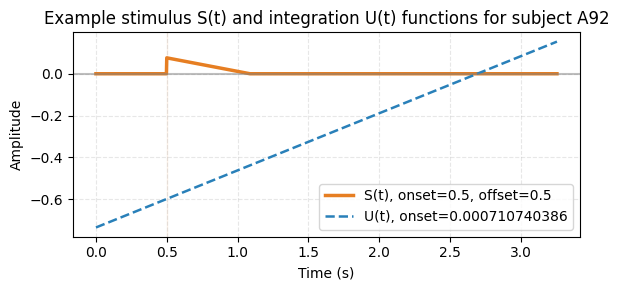

Subject A92: Tbar=2.844, Dbar=1.728, offFix=1.360
Proporción empírica de lados: {'L': 0.32623527681288966, 'C': 0.33931501114492935, 'R': 0.334449712042181}
duration = 0.0, onsetS = 1.360300064086914, offset = 1.360300064086914
duration = 0.05, onsetS = 1.310300064086914, offset = 1.360300064086914
duration = 0.1, onsetS = 1.260300064086914, offset = 1.360300064086914
duration = 0.15000000000000002, onsetS = 1.2103000640869142, offset = 1.360300064086914
duration = 0.2, onsetS = 1.160300064086914, offset = 1.360300064086914
duration = 0.25, onsetS = 1.110300064086914, offset = 1.360300064086914
duration = 0.30000000000000004, onsetS = 1.060300064086914, offset = 1.360300064086914
duration = 0.35000000000000003, onsetS = 1.010300064086914, offset = 1.360300064086914
duration = 0.4, onsetS = 0.960300064086914, offset = 1.360300064086914
duration = 0.45, onsetS = 0.9103000640869141, offset = 1.360300064086914
duration = 0.5, onsetS = 0.8603000640869141, offset = 1.360300064086914
duration

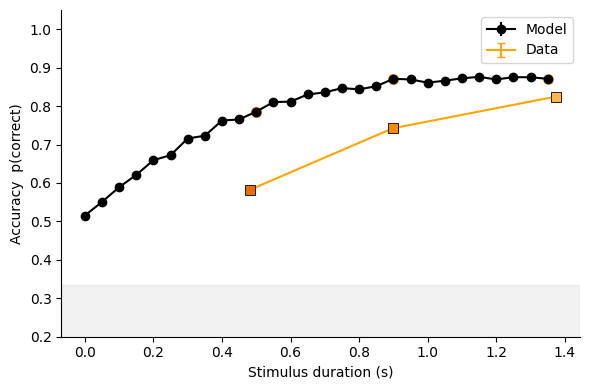

In [ ]:
subject = 'A92'
step_dur = 0.05
M = 1000
dt = 0.1/40
th = (0.5, 0.5, 0.5)
SUBSAMPLE_MODEL = 600  


df_nonsil = df[(df['ttype_c'] != 'SIL')].copy()
df_subj   = df_nonsil[df_nonsil['subject'] == subject].copy()

df_subj['stim_duration']  = df_subj['offset'] - df_subj['onset']
df_subj['delay_duration'] = df_subj['timepoint_4'] - df_subj['offset']
df_subj = df_subj[(df_subj['stim_duration'] >= 0) & (df_subj['delay_duration'] >= 0)].copy()

Tbar   = float(df_subj['timepoint_4'].median())
Dbar   = float(df_subj['delay_duration'].median())
offFix = max(0.0, min(Tbar - Dbar, Tbar))
offFix = float(df_subj['timepoint_3'].median())

print(f"Subject {subject}: Tbar={Tbar:.3f}, Dbar={Dbar:.3f}, offFix={offFix:.3f}")


side_props = (df_subj['x_c'].value_counts(normalize=True)
              .reindex(['L','C','R'])
              .fillna(0.0)
              .to_dict())
print(f"Proporción empírica de lados: {side_props}")

N = int(Tbar / dt)
t = np.linspace(0.0, Tbar, N, endpoint=False)

U_t = get_U_fn(theta['U_amp'], theta['U_base'], theta['U_on'], Tbar)(t).astype(np.float64, copy=False)

durations = np.arange(0.0, offFix + 1e-12, step_dur)
p_model = np.zeros_like(durations, dtype=float)
p_model_sem = np.zeros_like(durations, dtype=float)


for i, dur in enumerate(durations):
    onsetS = max(0.0, offFix - dur)
    S_t = get_S_fn(theta['S_amp'], theta['S_d'], onsetS, offFix)(t).astype(np.float64, copy=False)

    mL, mC, mR = simulate_counts_one_trial_heun(
        S_t, U_t, 0,  # side_code L
        theta['sL'], theta['sC'], theta['sR'],
        theta['noise'], dt, th[0], th[1], th[2], M
    )
    p_L = mL / M

    mL_c, mC_c, mR_c = simulate_counts_one_trial_heun(
        S_t, U_t, 1,  # side_code C
        theta['sL'], theta['sC'], theta['sR'],
        theta['noise'], dt, th[0], th[1], th[2], M
    )
    p_C = mC_c / M

    mL_r, mC_r, mR_r = simulate_counts_one_trial_heun(
        S_t, U_t, 2,  # side_code R
        theta['sL'], theta['sC'], theta['sR'],
        theta['noise'], dt, th[0], th[1], th[2], M
    )
    p_R = mR_r / M

    p_bar = (p_L + p_C + p_R) / 3.0
    var_L = p_L * (1.0 - p_L) / M
    var_C = p_C * (1.0 - p_C) / M
    var_R = p_R * (1.0 - p_R) / M
    sem_bar = np.sqrt((var_L + var_C + var_R) / 9.0)

    p_model[i] = p_bar
    p_model_sem[i] = sem_bar

x_real, y_real, yerr_real, labs = [], [], [], []
for stimd in stim_order:
    block = df_subj[df_subj['stimd_c'] == stimd]
    n = len(block)
    if n == 0: 
        continue
    x_mu = float(block['stim_duration'].median())
    y_mu = float(block['correct_bool'].mean())
    y_se = float(block['correct_bool'].std(ddof=1) / np.sqrt(n)) if n > 1 else 0.0
    x_real.append(x_mu); y_real.append(y_mu); yerr_real.append(y_se); labs.append(stimd)

plt.figure(figsize=(6, 4))
plt.errorbar(durations, p_model, yerr=p_model_sem, fmt='-o', color='black', capsize=0,
             label='Model')
for xr, yr, ye, stimd in zip(x_real, y_real, yerr_real, labs):
    plt.errorbar([xr], [yr], yerr=[ye], fmt='s', markersize=7, capsize=3,
                 color=stim_colors[stimd], mec='black', mew=0.6)
plt.errorbar(x_real, y_real, yerr=yerr_real,zorder = 0, color='orange', markersize=7, capsize=3, label = 'Data')

for xr, stimd in zip(x_real, labs):
    k = int(round(xr / step_dur))
    k = max(0, min(k, len(durations)-1))
    if not np.isnan(p_model[k]):
        plt.plot(durations[k], p_model[k], marker='o', markersize=7,
                 color=stim_colors[stimd], alpha=0.85, linestyle='None')


plt.axhspan(0, 1/3, color='gray', alpha=0.1)
plt.xlabel('Stimulus duration (s)')
plt.ylabel('Accuracy  p(correct)')
plt.ylim(0.2, 1.05)
sns.despine()
plt.tight_layout()
plt.legend()
plt.show()

### Offset

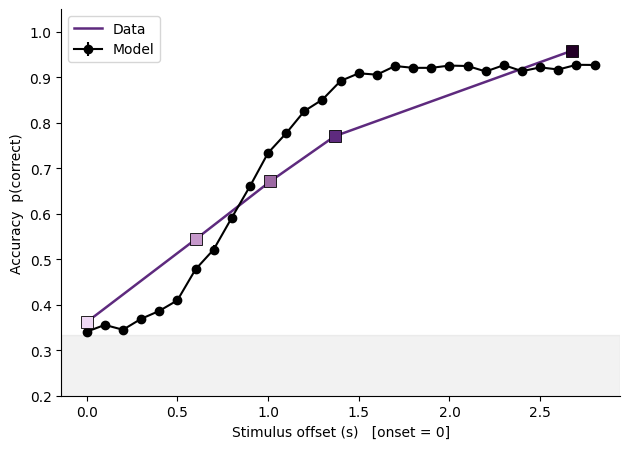

In [ ]:
df_subj = df[df['subject'] == subject].copy()
df_subj['stim_duration'] = df_subj['offset'] - df_subj['onset']
df_subj['delay_duration'] = df_subj['timepoint_4'] - df_subj['offset']
df_subj = df_subj[(df_subj['stim_duration'] >= 0) & (df_subj['delay_duration'] >= 0)].copy()

Tbar = float(df_subj['timepoint_4'].median())
N = int(Tbar / dt)
t = np.linspace(0.0, Tbar, N, endpoint=False)
U_t = get_U_fn(theta['U_amp'], theta['U_base'], theta['U_on'], Tbar)(t).astype(np.float64, copy=False)

from sim_core_numba import simulate_counts_one_trial_heun

offsets = np.arange(0.0, Tbar + 1e-12, 0.1)
p_model = np.zeros_like(offsets, dtype=float)
p_model_sem = np.zeros_like(offsets, dtype=float)

for i, offS in enumerate(offsets):
    onsetS = 0.0 
    S_t = get_S_fn(theta['S_amp'], theta['S_d'], onsetS, offS)(t).astype(np.float64, copy=False)

    mL, mC, mR = simulate_counts_one_trial_heun(S_t, U_t, 0,
        theta['sL'], theta['sC'], theta['sR'], theta['noise'], dt, *th, M)
    p_L = mL / M

    mL, mC, mR = simulate_counts_one_trial_heun(S_t, U_t, 1,
        theta['sL'], theta['sC'], theta['sR'], theta['noise'], dt, *th, M)
    p_C = mC / M

    mL, mC, mR = simulate_counts_one_trial_heun(S_t, U_t, 2,
        theta['sL'], theta['sC'], theta['sR'], theta['noise'], dt, *th, M)
    p_R = mR / M

    p_bar = (p_L + p_C + p_R) / 3.0
    var = (p_L*(1-p_L) + p_C*(1-p_C) + p_R*(1-p_R)) / (9*M)
    p_model[i] = p_bar
    p_model_sem[i] = np.sqrt(var)


x_delay, y_delay, yerr_delay, labs_delay = [], [], [], []
for tt in delay_types:
    block = df_subj[df_subj['ttype_c'] == tt]
    n = len(block)
    if n == 0:
        continue
    x_mu = float(block['offset'].median())     # posición X = media del offset
    y_mu = float(block['correct_bool'].mean())  # accuracy
    y_se = float(block['correct_bool'].std(ddof=1) / np.sqrt(n)) if n > 1 else 0.0
    x_delay.append(x_mu); y_delay.append(y_mu); yerr_delay.append(y_se); labs_delay.append(tt)


plt.figure(figsize=(6.4, 4.6))
plt.errorbar(offsets, p_model, yerr=p_model_sem, fmt='-o', color='black', capsize=0,
             label='Model')

order = np.argsort(x_delay)
x_sorted = np.array(x_delay)[order]
y_sorted = np.array(y_delay)[order]
yerr_sorted = np.array(yerr_delay)[order]
labels_sorted = np.array(labs_delay)[order]

plt.plot(
    x_sorted, y_sorted, '-',
    color='#5E2A7E', linewidth=1.8,
    label='Data'
)
for xd, yd, ye, tt in zip(x_sorted, y_sorted, yerr_sorted, labels_sorted):
    plt.errorbar(
        xd, yd, yerr=ye, fmt='s', markersize=8, capsize=3,
        color=delay_colors[tt], ecolor=delay_colors[tt],
        mec='black', mew=0.6, elinewidth=1.2, zorder=3
    )


plt.axhspan(0, 1/3, color='gray', alpha=0.1)
plt.xlabel('Stimulus offset (s)   [onset = 0]')
plt.ylabel('Accuracy  p(correct)')
plt.ylim(0.2, 1.05)
plt.tight_layout()
plt.legend()
sns.despine()
plt.show()

### Delay duration

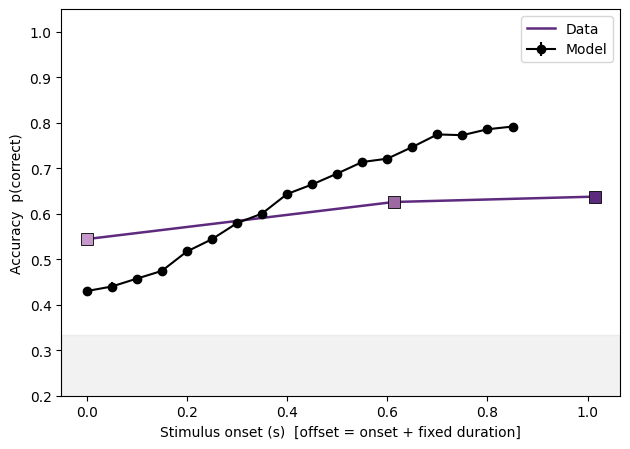

In [ ]:
df_ss = df[(df['subject'] == subject) & (df['stimd_c'] == 'SS') &
           (df['ttype_c'].isin(['DS','DM','DL']))].copy()


df_ss['stim_duration']  = df_ss['offset'] - df_ss['onset']
df_ss['delay_duration'] = df_ss['timepoint_4'] - df_ss['offset']
df_ss = df_ss[(df_ss['stim_duration'] >= 0) & (df_ss['delay_duration'] >= 0)].copy()


dur_fix = float(df_ss['stim_duration'].median())
Tbar = float(df_ss['timepoint_4'].median())
T_corr = float(df_ss['timepoint_3'].median())
N = int(Tbar / dt)
t = np.linspace(0.0, Tbar, N, endpoint=False)
U_t = get_U_fn(theta['U_amp'], theta['U_base'], theta['U_on'], Tbar)(t).astype(np.float64, copy=False)


onsets = np.arange(0.0, max(0.0, T_corr - dur_fix) + 1e-12, 0.1)
p_model = np.zeros_like(onsets, dtype=float)
p_model_sem = np.zeros_like(onsets, dtype=float)

for i, onsetS in enumerate(onsets):
    offsetS = onsetS + dur_fix
    S_t = get_S_fn(theta['S_amp'], theta['S_d'], onsetS, offsetS)(t).astype(np.float64, copy=False)

    mL, mC, mR = simulate_counts_one_trial_heun(S_t, U_t, 0,
        theta['sL'], theta['sC'], theta['sR'], theta['noise'], dt, th[0], th[1], th[2], M)
    p_L = mL / M
    mL_c, mC_c, mR_c = simulate_counts_one_trial_heun(S_t, U_t, 1,
        theta['sL'], theta['sC'], theta['sR'], theta['noise'], dt, th[0], th[1], th[2], M)
    p_C = mC_c / M
    mL_r, mC_r, mR_r = simulate_counts_one_trial_heun(S_t, U_t, 2,
        theta['sL'], theta['sC'], theta['sR'], theta['noise'], dt, th[0], th[1], th[2], M)
    p_R = mR_r / M

    p_bar = (p_L + p_C + p_R) / 3.0
    var = (p_L*(1-p_L) + p_C*(1-p_C) + p_R*(1-p_R)) / (9*M)
    p_model[i] = p_bar
    p_model_sem[i] = np.sqrt(var)

x_data, y_data, yerr_data, labs_data = [], [], [], []
for tt in delay_types:
    blk = df_ss[df_ss['ttype_c'] == tt]
    n = len(blk)
    if n == 0:
        continue
    x_mu = float(blk['onset'].median())          
    y_mu = float(blk['correct_bool'].mean())
    y_se = float(blk['correct_bool'].std(ddof=1)/np.sqrt(n)) if n > 1 else 0.0
    x_data.append(x_mu); y_data.append(y_mu); yerr_data.append(y_se); labs_data.append(tt)

# ========= Plot =========
plt.figure(figsize=(6.4, 4.6))

plt.errorbar(onsets, p_model, yerr=p_model_sem, fmt='-o', color='black', capsize=0,
             label=f'Model')
order = np.argsort(x_data)
x_sorted = np.array(x_data)[order]
y_sorted = np.array(y_data)[order]
yerr_sorted = np.array(yerr_data)[order]
labs_sorted = np.array(labs_data)[order]
plt.plot(x_sorted, y_sorted, '-', color='#5E2A7E', linewidth=1.8, label='Data')
for xd, yd, ye, tt in zip(x_sorted, y_sorted, yerr_sorted, labs_sorted):
    plt.errorbar([xd], [yd], yerr=[ye], fmt='s', markersize=8, capsize=3,
                 color=delay_colors[tt], ecolor=delay_colors[tt],
                 mec='black', mew=0.6, elinewidth=1.2, zorder=3)
plt.axhspan(0, 1/3, color='gray', alpha=0.1)
plt.xlabel('Stimulus onset (s)  [offset = onset + fixed duration]')
plt.ylabel('Accuracy  p(correct)')
plt.ylim(0.2, 1.05)
plt.tight_layout()
plt.legend()
plt.show() 

### Unified

# Continuous variables simulation

### Helpers

In [ ]:
from helpers.sim_core_numba import simulate_counts_one_trial_heun

# --- parámetros del sujeto ---
# row = params_df.loc[params_df['subject'] == f'{subject}_crn'].iloc[0]
# theta = dict(
#     sL=float(row['sL']), sC=float(row['sC']), sR=float(row['sR']),
#     noise=float(row['noise_amp']),
#     S_amp=float(row['S_amplitude']), S_d=float(row['S_d']),
#     U_amp=float(row['U_int_amplitude']), U_base=float(row['U_int_baseline']),
#     U_on=float(row['U_int_onset']),
# )

# ===== utilidades =====
def get_onset_offset(stim_dur, delay_dur, t1, t2, t3, t4):
    if stim_dur == 'VG': return 0.0, t4
    if stim_dur == 'SS':
        if delay_dur == 'DS': return t2, t3
        if delay_dur == 'DM': return t1, t2
        if delay_dur == 'DL': return 0.0, t1
    if stim_dur == 'SM':
        if delay_dur == 'DS': return t1, t3
        if delay_dur == 'DM': return 0.0, t2
    if stim_dur == 'SL': return 0.0, t3
    if stim_dur == 'SIL': return 0.0, 0.0
    raise ValueError

def get_U_fn(amplitude, baseline, onset, offset):
    def U(t):
        t = np.asarray(t, dtype=np.float64)
        D = float(offset) - float(onset)
        u = np.full_like(t, float(baseline), dtype=np.float64)
        if D <= 0.0: return u
        active = (t >= onset) & (t <= offset)
        u[active] = baseline + amplitude * (t[active] - onset) / D
        return u
    return U

def get_S_fn(amplitude, d, onset, offset):
    def S(t):
        S_base = np.where((t >= onset) & (t <= offset), amplitude, 0.0)
        tail   = np.where((t > offset) & (t <= offset + d),
                          amplitude * (1.0 - (t - offset) / d), 0.0)
        return np.maximum(S_base, tail)
    return S

side_map = {'L':0, 'C':1, 'R':2}

def build_SU_for_trial(r):
    on, off = get_onset_offset(r['stimd_c'], r['ttype_c'],
                               r['timepoint_1'], r['timepoint_2'],
                               r['timepoint_3'], r['timepoint_4'])
    T = float(r['timepoint_4'])
    N = int(T / dt)
    if N <= 0: return None, None, 0
    t = np.linspace(0.0, T, N, endpoint=False)
    S_t = get_S_fn(theta['S_amp'], theta['S_d'], float(on), float(off))(t).astype(np.float64, copy=False)
    U_t = get_U_fn(theta['U_amp'], theta['U_base'], theta['U_on'], T)(t).astype(np.float64, copy=False)
    return np.ascontiguousarray(S_t), np.ascontiguousarray(U_t), N

def sem_from_bool(x):
    n = len(x)
    if n <= 1: return 0.0
    p = float(np.mean(x))
    return np.sqrt(p*(1-p)/n)

def model_mean_for_trials(trials):
    pc = []
    for _, r in trials.iterrows():
        side_true = r['x_c']; code = side_map[side_true]
        S_t, U_t, N = build_SU_for_trial(r)
        if N <= 0: 
            continue
        # mL, mC, mR = simulate_counts_one_trial_heun(
        #     S_t, U_t, code,
        #     theta['sL'], theta['sC'], theta['sR'],
        #     theta['noise'], dt, th[0], th[1], th[2], M
        # )
        mL, mC, mR = simulate_counts_one_trial_heun_jl(
            S_t, U_t, code,
            theta, dt, th, M, seed=12345
        )
        pc.append( (mL if side_true=='L' else mC if side_true=='C' else mR) / M )
    if len(pc) == 0:
        return np.nan, np.nan
    pc = np.asarray(pc, float)
    mean = float(pc.mean())
    sem  = float(pc.std(ddof=1) / np.sqrt(len(pc))) if len(pc) > 1 else 0.0
    return mean, sem


subject = 'A92'

dt = 0.1/40
th = (0.5, 0.5, 0.5)
SUBSAMPLE_PER_BIN = 600
stim_colors = {'SS': '#EF6C00', 'SM': '#FB8C00', 'SL': '#FFB74D'}
stim_order  = ['SS','SM','SL']
delay_types = ['VG', 'DS', 'DM', 'DL', 'SIL']
delay_colors = dict(zip(delay_types, ['#230027', '#5E2A7E', '#9C69A3', '#C698CB', '#EFD9F5']))

delay_duration_colors = {k: delay_colors[k] for k in ['DS', 'DM', 'DL']}
colors = {'delay_duration': delay_duration_colors, 'offset': delay_colors, 'stim_duration': stim_colors}
order = {'delay_duration': ['DS', 'DM', 'DL'], 'offset': delay_types, 'stim_duration': stim_order}


### Stimulus duration

In [ ]:
# ===== Config =====
M = 300                   # trayectorias por trial (modelo)
n_bins = 12

# ===== datos del sujeto =====
if 'onset' not in df.columns or 'offset' not in df.columns:
    df[['onset','offset']] = df.apply(
        lambda r: pd.Series(get_onset_offset(r['stimd_c'], r['ttype_c'],
                                             r['timepoint_1'], r['timepoint_2'],
                                             r['timepoint_3'], r['timepoint_4'])),
        axis=1
    )

df['stim_duration']  = df['offset'] - df['onset']
df['delay_duration'] = df['timepoint_4'] - df['offset']

df_subj = df[
    (df['subject']==subject) &
    (df['ttype_c']!='SIL') &
    (df['stim_duration']>=0) & (df['delay_duration']>=0)
].copy()

# ===== binning por stim_duration (quantiles) =====
df_subj['stim_bin'], bin_edges = pd.qcut(df_subj['stim_duration'], n_bins, retbins=True, duplicates='drop')

# centros por mediana (ordenados)
centros = (df_subj.groupby('stim_bin', observed=True)['stim_duration']
           .median().rename('center').reset_index().sort_values('center'))
bin_order = list(centros['stim_bin'])
x_centers = centros['center'].to_numpy()

# ===== recorrer bins =====
y_data, y_data_sem = [], []
y_model, y_model_sem = [], []

for cat in bin_order:
    bin_trials = df_subj[df_subj['stim_bin']==cat]

    # cap opcional para acelerar y mantener mezcla de lados
    if len(bin_trials) > SUBSAMPLE_PER_BIN:
        parts = []
        for s in ['L','C','R']:
            g = bin_trials[bin_trials['x_c']==s]
            k = min(len(g), SUBSAMPLE_PER_BIN//3)
            parts.append(g.sample(k, random_state=0))
        bin_trials = pd.concat(parts, axis=0)

    # --- datos (media y SEM binomial)
    acc = bin_trials['correct_bool'].to_numpy(dtype=float)
    y_data.append(float(np.mean(acc)))
    y_data_sem.append(sem_from_bool(acc))

    m, s = model_mean_for_trials(bin_trials)
    y_model.append(m)
    y_model_sem.append(s)

y_data  = np.array(y_data);  
y_data_sem  = np.array(y_data_sem)
y_model = np.array(y_model); 
y_model_sem = np.array(y_model_sem)

# ===== plot: UNA línea datos y UNA línea modelo =====
plt.figure(figsize=(7,4.5))
plt.errorbar(x_centers, y_model, yerr=y_model_sem, fmt='-o', color='black',
             capsize=3, label='Model', markersize=6)
plt.errorbar(x_centers, y_data, yerr=y_data_sem, fmt='--o', color='#555555',
             capsize=3, label='Data', markersize=6)

# Plot individual stimulus type points
stim_x = []
stim_y = []
for stimd in stim_order:
    b = df_subj[df_subj['stimd_c']==stimd]
    if len(b)==0: continue
    stim_x.append(float(b['stim_duration'].median()))
    stim_y.append(float(b['correct_bool'].mean()))
    plt.plot(stim_x[-1],stim_y[-1],'s', ms=7, mec='black', mfc=stim_colors[stimd], label=stimd)
plt.plot(stim_x, stim_y, '-', color='orange', lw=2, alpha=0.7)



plt.axhspan(0, 1/3, color='gray', alpha=0.1, zorder=0)
plt.xlabel('Stimulus duration (s)')
plt.ylabel('Accuracy  p(correct)')
plt.ylim(0.2, 1.05)
sns.despine()
plt.legend()
plt.tight_layout()
plt.show()

NameError: name 'theta' is not defined

### Offset

In [ ]:
n_bins = 10              
M = 300                   
subject = 'A89'

df_subj = df[
    (df['subject']==subject) &
    (df['stim_duration']>=0) & (df['delay_duration']>=0)
].copy()

bin_var = 'offset'
df_subj['off_bin'], off_edges = pd.qcut(df_subj[bin_var], n_bins, retbins=True, duplicates='drop')

centros = (df_subj.groupby('off_bin', observed=True)[bin_var].median().rename('center').reset_index().sort_values('center'))
bin_order = list(centros['off_bin'])
x_centers = centros['center'].to_numpy()

y_data, y_data_sem = [], []
y_model, y_model_sem = [], []

for cat in bin_order:
    bin_trials = df_subj[df_subj['off_bin']==cat]

    if len(bin_trials) > SUBSAMPLE_PER_BIN:
        parts = []
        for s in ['L','C','R']:
            g = bin_trials[bin_trials['x_c']==s]
            k = min(len(g), SUBSAMPLE_PER_BIN//3)
            parts.append(g.sample(k, random_state=0))
        bin_trials = pd.concat(parts, axis=0)

    acc = bin_trials['correct_bool'].to_numpy(dtype=float)
    y_data.append(float(np.mean(acc)))
    y_data_sem.append(sem_from_bool(acc))

    m, s = model_mean_for_trials(bin_trials)
    y_model.append(m)
    y_model_sem.append(s)

y_data  = np.array(y_data) 
y_data_sem  = np.array(y_data_sem)
y_model = np.array(y_model)
y_model_sem = np.array(y_model_sem)

x_delay, y_delay, yerr_delay, labs_delay = [], [], [], []
for tt in delay_types:
    block = df_subj[df_subj['ttype_c'] == tt]
    n = len(block)
    if n == 0: continue
    x_mu = float(block['offset'].median())
    y_mu = float(block['correct_bool'].mean())
    y_se = float(block['correct_bool'].std(ddof=1) / np.sqrt(n)) if n > 1 else 0.0
    x_delay.append(x_mu);
    y_delay.append(y_mu); 
    yerr_delay.append(y_se); 
    labs_delay.append(tt)


# def model_mean_for_trials(trials):
#     pc = []
#     for _, r in trials.iterrows():
#         side_true = r['x_c']; code = side_map[side_true]
#         S_t, U_t, N = build_SU_for_trial(r)
#         if N <= 0: continue
#         mL, mC, mR = simulate_counts_one_trial_heun( S_t, U_t, code, theta['sL'], theta['sC'], theta['sR'], theta['noise'], dt, th[0], th[1], th[2], M)
#         pc.append( (mL if side_true=='L' else mC if side_true=='C' else mR) / M )
#     if len(pc)==0:
#         return np.nan, np.nan
#     pc = np.asarray(pc, float)
#     mean = float(pc.mean())
#     sem  = float(pc.std(ddof=1)/np.sqrt(len(pc))) if len(pc)>1 else 0.0
#     return mean, sem


x_plot = x_centers
y_data_plot, y_data_sem_plot = y_data, y_data_sem
y_model_plot, y_model_sem_plot = y_model, y_model_sem

plt.figure(figsize=(7,4.5))

plt.errorbar(x_plot, y_model_plot, yerr=y_model_sem_plot, fmt='-o', color='black', capsize=3, label='Model', markersize=6)
plt.errorbar(x_plot, y_data_plot, yerr=y_data_sem_plot, fmt='--o', color='#555555', capsize=3, label='Data', markersize=6)

for i, tt in enumerate(labs_delay):
    c = delay_colors.get(tt, '#777777')
    # plt.errorbar(x_delay[i], y_delay[i], yerr=yerr_delay[i], fmt='s', markersize=8, capsize=3,
    #              color=c, ecolor=c, mec='black', mew=0.6, elinewidth=1.2,
    #              label=tt)
x_sorted = np.array(x_delay)[np.argsort(x_delay)]
y_sorted = np.array(y_delay)[np.argsort(x_delay)]
yerr_sorted = np.array(yerr_delay)[np.argsort(x_delay)]
# plt.plot(x_sorted, y_sorted, '-', color='purple', linewidth=1.0, alpha=0.7)

plt.axhspan(0, 1/3, color='gray', alpha=0.1, zorder=0)
plt.xlabel('Stimulus offset (s)')
plt.ylabel('Accuracy  p(correct)')
plt.ylim(0.2, 1.05)

# Quitar duplicados en la leyenda conservando colores
handles, labels = plt.gca().get_legend_handles_labels()
uniq = dict(zip(labels, handles))
plt.legend(uniq.values(), uniq.keys(), ncol=2)

sns.despine()
plt.tight_layout()
plt.show()

KeyError: 'stim_duration'

### Average across subj

In [ ]:
n_bins = 10
M = 300

to_plot = df[df['timepoint_4']<= np.percentile(df['timepoint_4'], 95)].copy()
to_plot = to_plot[to_plot['onset']==0]

bin_var = 'delay_duration'
to_plot['off_bin'], off_edges = pd.qcut(to_plot[bin_var], n_bins, retbins=True, duplicates='drop')
centros = (to_plot.groupby('off_bin', observed=True)[bin_var]
        .median().rename('center').reset_index().sort_values('center'))
bin_order = list(centros['off_bin'])
x_centers = centros['center'].to_numpy()

y_data, y_data_sem = [], []
y_model, y_model_sem = [], []

def _nansem(a, axis=0):
    a = np.asarray(a, float)
    n = np.sum(~np.isnan(a), axis=axis)
    dd = np.where(n > 1, 1, 0)
    s = np.nanstd(a, axis=axis, ddof=0) 
    s = s * np.sqrt(np.maximum(n, 1) / np.maximum(n - dd, 1))
    return s / np.sqrt(np.maximum(n, 1))

data_mat, model_mat = [], []
sil_xs, sil_data, sil_model = [], [], []

for subject in params_df['subject'].unique():
    df_subj = to_plot[to_plot['subject'] == subject].copy()

    row = params_df.loc[params_df['subject'] == subject].iloc[0]
    theta = dict(
        sL=float(row['sL']), sC=float(row['sC']), sR=float(row['sR']), noise=float(row['noise_amp']), S_amp=float(row['S_amplitude']), S_d=float(row['S_d']), U_amp=float(row['U_int_amplitude']), U_base=float(row['U_int_baseline']), U_on=float(row['U_int_onset']))

    subj_data, subj_model = [], []

    for cat in bin_order:
        bin_trials = df_subj[df_subj['off_bin'] == cat]

        if len(bin_trials) > SUBSAMPLE_PER_BIN:
            parts = []
            for s in ['L','C','R']:
                g = bin_trials[bin_trials['x_c'] == s]
                k = min(len(g), SUBSAMPLE_PER_BIN//3)
                if k > 0:
                    parts.append(g.sample(k, random_state=0))
            if len(parts):
                bin_trials = pd.concat(parts, axis=0)

        if len(bin_trials) == 0:
            subj_data.append(np.nan)
            subj_model.append(np.nan)
        else:
            acc = bin_trials['correct_bool'].to_numpy(dtype=float)
            subj_data.append(float(np.mean(acc)))

            m, _s = model_mean_for_trials(bin_trials)
            subj_model.append(m)

    data_mat.append(subj_data)
    model_mat.append(subj_model)


data_mat   = np.asarray(data_mat, float)   
model_mat  = np.asarray(model_mat, float) 

y_data_mean   = np.nanmean(data_mat, axis=0)
y_model_mean  = np.nanmean(model_mat, axis=0)
y_data_sem_s  = _nansem(data_mat, axis=0)
y_model_sem_s = _nansem(model_mat, axis=0)

x_plot_mean      = x_centers
y_data_plot_mean = y_data_mean
y_data_sem_mean  = y_data_sem_s
y_model_plot_mean= y_model_mean
y_model_sem_mean = y_model_sem_s



KeyError: 'onset'

In [ ]:
print(bin_var)

offset


In [ ]:
n_bins = 10
M = 300
def _nansem(a, axis=0):
    a = np.asarray(a, float)
    n = np.sum(~np.isnan(a), axis=axis)
    dd = np.where(n > 1, 1, 0)
    s = np.nanstd(a, axis=axis, ddof=0) 
    s = s * np.sqrt(np.maximum(n, 1) / np.maximum(n - dd, 1))
    return s / np.sqrt(np.maximum(n, 1))

def model_data_mean(to_plot, bin_var, n_bins):
    
    to_plot['off_bin'], off_edges = pd.qcut(to_plot[bin_var], n_bins, retbins=True, duplicates='drop')
    centros = (to_plot.groupby('off_bin', observed=True)[bin_var]
            .median().rename('center').reset_index().sort_values('center'))
    bin_order = list(centros['off_bin'])
    x_centers = centros['center'].to_numpy()

    y_data, y_data_sem = [], []
    y_model, y_model_sem = [], []


    data_mat, model_mat = [], []
    sil_xs, sil_data, sil_model = [], [], []

    for subject in params_df['subject'].unique():
        df_subj = to_plot[to_plot['subject'] == subject].copy()

        row = params_df.loc[params_df['subject'] == subject].iloc[0]
        theta = dict(
            sL=float(row['sL']), sC=float(row['sC']), sR=float(row['sR']), noise=float(row['noise_amp']), S_amp=float(row['S_amplitude']), S_d=float(row['S_d']), U_amp=float(row['U_int_amplitude']), U_base=float(row['U_int_baseline']), U_on=float(row['U_int_onset']))

        subj_data, subj_model = [], []

        for cat in bin_order:
            bin_trials = df_subj[df_subj['off_bin'] == cat]

            if len(bin_trials) > SUBSAMPLE_PER_BIN:
                parts = []
                for s in ['L','C','R']:
                    g = bin_trials[bin_trials['x_c'] == s]
                    k = min(len(g), SUBSAMPLE_PER_BIN//3)
                    if k > 0:
                        parts.append(g.sample(k, random_state=0))
                if len(parts):
                    bin_trials = pd.concat(parts, axis=0)

            if len(bin_trials) == 0:
                subj_data.append(np.nan)
                subj_model.append(np.nan)
            else:
                acc = bin_trials['correct_bool'].to_numpy(dtype=float)
                subj_data.append(float(np.mean(acc)))

                m, _s = model_mean_for_trials(bin_trials)
                subj_model.append(m)

        data_mat.append(subj_data)
        model_mat.append(subj_model)


    data_mat   = np.asarray(data_mat, float)   
    model_mat  = np.asarray(model_mat, float) 

    y_data_mean   = np.nanmean(data_mat, axis=0)
    y_model_mean  = np.nanmean(model_mat, axis=0)
    y_data_sem_s  = _nansem(data_mat, axis=0)
    y_model_sem_s = _nansem(model_mat, axis=0)

    x_plot_mean      = x_centers
    y_data_plot_mean  = y_data_mean
    y_data_sem_mean   = y_data_sem_s
    y_model_plot_mean = y_model_mean
    y_model_sem_mean  = y_model_sem_s

    return (data_mat, model_mat, x_centers)

params_df = params_df[params_df['subject']!= 'A92']
to_plot = df[df['timepoint_4']<= np.percentile(df['timepoint_4'], 95)].copy()
to_plot = to_plot[to_plot['onset']==0]
to_plot2 = to_plot[to_plot['ttype_c']!='VG']
print(f'Number of sessions delay {len(to_plot[["subject", "session"]].drop_duplicates())}')
print(f'Number of trials delay: {len(to_plot["trial"])}')
print(f'Number of sessions stimulus {len(to_plot2[["subject", "session"]].drop_duplicates())}')
print(f'Number of trials delay: {len(to_plot2["trial"])}')
data_stim, model_stim,bins_stim = model_data_mean(to_plot2, 'offset', 8)
data_delay, model_delay, bins_delay = model_data_mean(to_plot, 'delay_duration', 8)


Number of sessions delay 1940
Number of trials delay: 111477
Number of sessions stimulus 1932
Number of trials delay: 86885


/var/folders/gk/r166p6nx2bb5zf2rlwww8fc00000gn/T/ipykernel_82157/3514506524.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name, n)


AttributeError: Line2D.set() got an unexpected keyword argument 'cmap'

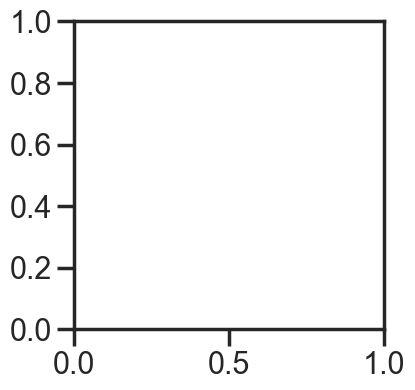

In [ ]:
from matplotlib import cm, colors

def truncate_colormap(cmap_name, minval=0.2, maxval=0.9, n=256):
    """Truncate a colormap to a subset of its range."""
    cmap = cm.get_cmap(cmap_name, n)
    new_cmap = colors.LinearSegmentedColormap.from_list(
        f"trunc({cmap_name},{minval:.2f},{maxval:.2f})",
        cmap(np.linspace(minval, maxval, n))
    )
    return new_cmap

trunc_purples = truncate_colormap('Purples_r', 0, 0.7)  # skip the lightest 30%
trunc_oranges = truncate_colormap('Oranges', 0.3, 1)  # skip the lightest 30%

plt.figure(figsize=(4,4))

plt.errorbar(x_plot_mean, y_model_plot_mean, yerr=y_model_sem_mean*1.96, fmt='-o', cmap = trunc_purples,
             capsize=3, label='Model (mean across subjects)', markersize=6)
plt.errorbar(x_plot_mean, y_data_plot_mean, yerr=y_data_sem_mean, fmt='--o', color='#555555',
             capsize=3, label='Data (mean across subjects)', markersize=6)
sns.lineplot(x=x_plot_mean,  y=y_model_plot_mean, ci=False, zorder=1, color='gray')
sns.lineplot(x=x_plot_mean,  y=y_model_plot_mean, hue=x_plot_mean,errorbar=('ci', 95), err_style="bars", marker='o', zorder=10, palette=trunc_purples, legend=False)
sns.lineplot(x=x_plot_mean,  y=y_data_plot_mean, ci=False, zorder=1, color='gray', linestyle='--')
sns.lineplot(x=x_plot_mean,  y=y_data_plot_mean, hue=x_plot_mean,errorbar=('ci', 95),  
             err_style="bars", marker='o', zorder=10, palette=trunc_purples, legend=False)
 
plt.axhspan(0, 1/3, color='gray', alpha=0.1, zorder=0)
plt.xlabel('Delay duration (s)')
plt.ylabel('Accuracy  p(correct)')
plt.ylim(0.2, 1.05)
plt.legend(ncol=1)
sns.despine()
plt.tight_layout()
plt.show()

In [ ]:
rows = []
subjects = list(params_df['subject'].unique())
for si, subj in enumerate(subjects):
    for bi, x in enumerate(bins_stim):
        d = data_stim[si, bi]
        m = model_stim[si, bi]
        if not np.isnan(d):
            rows.append({'center': float(x), 'acc': float(d), 'kind': 'Data',  'subject': subj})
        if not np.isnan(m):
            rows.append({'center': float(x), 'acc': float(m), 'kind': 'Model', 'subject': subj})

plot_stim= pd.DataFrame(rows)

rows = []
subjects = list(params_df['subject'].unique())
for si, subj in enumerate(subjects):
    for bi, x in enumerate(bins_delay):
        d = data_delay[si, bi]
        m = model_delay[si, bi]
        if not np.isnan(d):
            rows.append({'center': float(x), 'acc': float(d), 'kind': 'Data',  'subject': subj})
        if not np.isnan(m):
            rows.append({'center': float(x), 'acc': float(m), 'kind': 'Model', 'subject': subj})


plot_delay = pd.DataFrame(rows)


/var/folders/gk/r166p6nx2bb5zf2rlwww8fc00000gn/T/ipykernel_82157/916188565.py:4: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', False)` for the same effect.

  sns.lineplot(x='center',  y='acc',  ax=axes[0], data=plot_delay[plot_delay['kind']=='Data'], ci=False,
/var/folders/gk/r166p6nx2bb5zf2rlwww8fc00000gn/T/ipykernel_82157/916188565.py:6: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', False)` for the same effect.

  sns.lineplot(x='center',  y='acc',  ax=axes[0], data=plot_delay[plot_delay['kind']=='Model'], ci=False,
/opt/homebrew/anaconda3/envs/pybads310/lib/python3.10/site-packages/matplotlib/cbook.py:1719: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return math.isfinite(val)
/opt/homebrew/anaconda3/envs/pybads310/lib/python3.10/site-packages/matplotlib/cbook.py:1719: FutureWarning: Calling float on a single element Series is depre

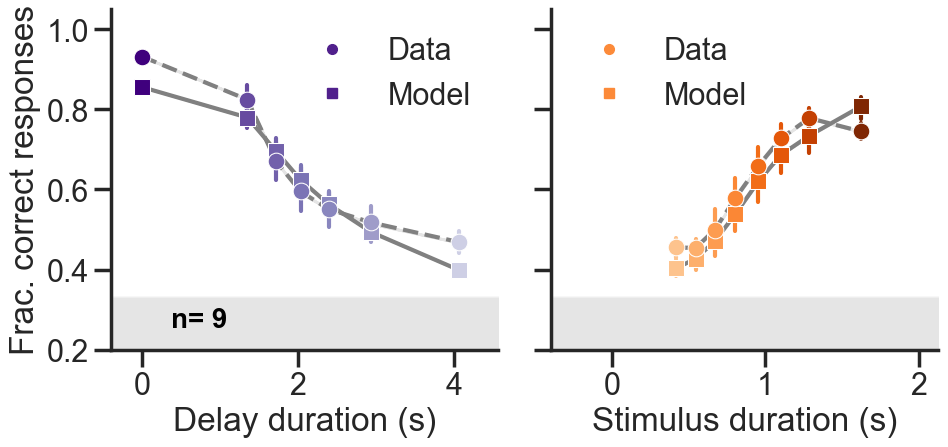

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 5), sharex=False, sharey=True)
axes=axes.flatten()

sns.lineplot(x='center',  y='acc',  ax=axes[0], data=plot_delay[plot_delay['kind']=='Data'], ci=False,  
              zorder=1, color='gray',  linestyle='--')
sns.lineplot(x='center',  y='acc',  ax=axes[0], data=plot_delay[plot_delay['kind']=='Model'], ci=False,  
              zorder=1, color='gray')
sns.lineplot(x='center',  y='acc', hue='center',  ax=axes[0], data=plot_delay[plot_delay['kind']=='Model'], errorbar=('ci', 95),  
             err_style="bars", marker='s', zorder=10, palette=trunc_purples, legend=False)
sns.lineplot(x='center',  y='acc', hue='center',  ax=axes[0], data=plot_delay[plot_delay['kind']=='Data'], errorbar=('ci', 95),  
             err_style="bars", marker='o', zorder=10, palette=trunc_purples, legend=False)


sns.lineplot(x='center',  y='acc',  ax=axes[1], data=plot_stim[plot_stim['kind']=='Data'], ci=False,  
              zorder=1, color='gray', linestyle='--')
sns.lineplot(x='center',  y='acc',  ax=axes[1], data=plot_stim[plot_stim['kind']=='Model'], ci=False,  
              zorder=1, color='gray')
sns.lineplot(x='center',  y='acc', hue='center',  ax=axes[1], data=plot_stim[plot_stim['kind']=='Model'], errorbar=('ci', 95),  
             err_style="bars", marker='s', zorder=10, palette=trunc_oranges, legend=False)
sns.lineplot(x='center',  y='acc', hue='center',  ax=axes[1], data=plot_stim[plot_stim['kind']=='Data'], errorbar=('ci', 95),  
             err_style="bars", marker='o', zorder=10, palette=trunc_oranges, legend=False)

# axes    
xmin = -0.4
lines_c = 'silver'
axes[0].set_xlabel('Delay duration (s)')
axes[0].set_ylabel('Frac. correct responses')
axes[0].set_ylim(0.2, 1.05)
axes[0].text(0.3, 0.05, 'n= '+str(len(subjects)), verticalalignment='bottom', horizontalalignment='right',
        transform=axes[0].transAxes, color='black', fontweight='bold', fontsize = 20)
xmax= plot_delay.center.max()+0.5
axes[0].fill_between(np.arange(xmin, xmax+1), 0.3333, 0.2, facecolor=lines_c, alpha=0.4)
axes[0].set_xlim(xmin, xmax)


from matplotlib.lines import Line2D

legend_delay = [
    Line2D([], [], color=trunc_purples(0.15), marker='o', linestyle='None',
           markersize=7, label='Data'),
    Line2D([], [], color=trunc_purples(0.15), marker='s', linestyle='None',
           markersize=7, label='Model')
]
axes[0].legend(handles=legend_delay, loc='best', frameon=False)
legend_stim = [
    Line2D([], [], color=trunc_oranges(0.3), marker='o', linestyle='None',
           markersize=7, label='Data'),
    Line2D([], [], color=trunc_oranges(0.3), marker='s', linestyle='None',
           markersize=7, label='Model')
]
axes[1].legend(handles=legend_stim, loc='best', frameon=False)

axes[1].set_xlabel('Stimulus duration (s)')
xmax= plot_stim.center.max()+0.5
axes[1].fill_between(np.arange(xmin, xmax+1), 0.3333, 0.2, facecolor=lines_c, alpha=0.4)
axes[1].set_xlim(-0.4, xmax)
sns.set()
sns.set_style('white')
sns.set_style('ticks')
sns.set_context("poster", font_scale=1)
sns.despine()
plt.tight_layout()
plt.savefig('fig_model_vs_data_all_subjects.png', dpi=300)
plt.savefig('fig_model_vs_data_all_subjects.svg')

### Delay duration

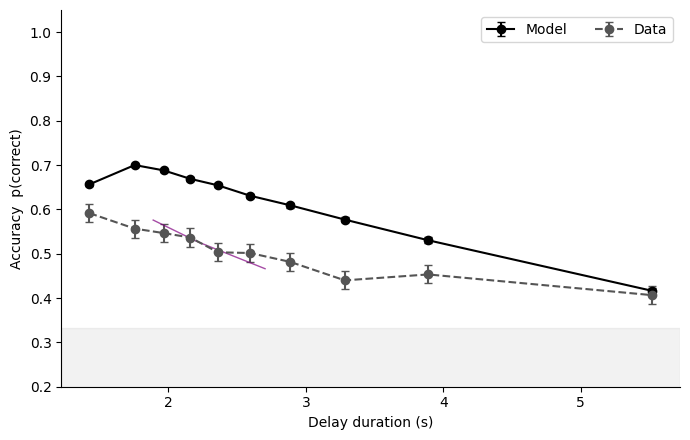

In [ ]:
# ===== datos del sujeto: SS y solo DS/DM/DL =====
if 'onset' not in df.columns or 'offset' not in df.columns:
    df[['onset','offset']] = df.apply(
        lambda r: pd.Series(get_onset_offset(r['stimd_c'], r['ttype_c'],
                                             r['timepoint_1'], r['timepoint_2'],
                                             r['timepoint_3'], r['timepoint_4'])),
        axis=1
    )

df['stim_duration']  = df['offset'] - df['onset']
df['delay_duration'] = df['timepoint_4'] - df['offset']

df_ss = df[
    (df['subject'] == subject) &
    (df['stimd_c'] == 'SS') &
    (df['ttype_c'].isin(delay_types)) &
    (df['stim_duration'] >= 0) & (df['delay_duration'] >= 0)
].copy()

bin_var = 'delay_duration'
df_ss['delay_bin'], edges = pd.qcut(df_ss[bin_var], n_bins, retbins=True, duplicates='drop')

centros = (df_ss.groupby('delay_bin', observed=True)[bin_var].median().rename('center').reset_index().sort_values('center'))

bin_order = list(centros['delay_bin'])
x_centers = centros['center'].to_numpy()

y_data, y_data_sem = [], []
y_model, y_model_sem = [], []

for cat in bin_order:
    bin_trials = df_ss[df_ss['delay_bin'] == cat]

    if len(bin_trials) > SUBSAMPLE_PER_BIN:
        parts = []
        for s in ['L','C','R']:
            g = bin_trials[bin_trials['x_c']==s]
            k = min(len(g), SUBSAMPLE_PER_BIN//3)
            parts.append(g.sample(k, random_state=0))
        bin_trials = pd.concat(parts, axis=0)

    acc = bin_trials['correct_bool'].to_numpy(dtype=float)
    y_data.append(float(np.mean(acc)))
    y_data_sem.append(sem_from_bool(acc))
    
    m, s = model_mean_for_trials(bin_trials)
    y_model.append(m)
    y_model_sem.append(s)

y_data  = np.array(y_data);  y_data_sem  = np.array(y_data_sem)
y_model = np.array(y_model); y_model_sem = np.array(y_model_sem)

x_delay, y_delay, yerr_delay, labs_delay = [], [], [], []
for tt in delay_types:
    block = df_ss[df_ss['ttype_c'] == tt]
    if len(block)==0: continue
    x_mu = float(block['delay_duration'].median())
    y_mu = float(block['correct_bool'].mean())
    y_se = float(block['correct_bool'].std(ddof=1)/np.sqrt(len(block))) if len(block)>1 else 0.0
    x_delay.append(x_mu); y_delay.append(y_mu); yerr_delay.append(y_se); labs_delay.append(tt)


plt.figure(figsize=(7,4.5))
plt.errorbar(x_centers, y_model, yerr=y_model_sem, fmt='-o', color='black', capsize=3, label='Model', markersize=6)
plt.errorbar(x_centers, y_data, yerr=y_data_sem, fmt='--o', color='#555555', capsize=3, label='Data', markersize=6)

plt.axhspan(0, 1/3, color='gray', alpha=0.1, zorder=0)
plt.xlabel('Delay duration (s)')
plt.ylabel('Accuracy  p(correct)')
plt.ylim(0.2, 1.05)

handles, labels = plt.gca().get_legend_handles_labels()
uniq = dict(zip(labels, handles))
plt.legend(uniq.values(), uniq.keys(), ncol=2)
sns.despine()
plt.tight_layout()
plt.show()

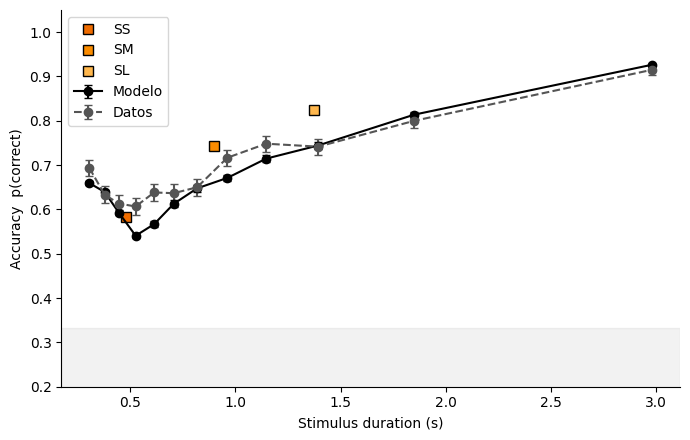

: 

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ===== Config =====
subject = 'A92'
n_bins = 12
M = 300                   # trayectorias por trial (modelo)
dt = 0.1/40
th = (0.5, 0.5, 0.5)
SUBSAMPLE_PER_BIN = 600
stim_colors = {'SS': '#EF6C00', 'SM': '#FB8C00', 'SL': '#FFB74D'}
stim_order  = ['SS','SM','SL']

from sim_core_numba import simulate_counts_one_trial_heun

# --- parámetros del sujeto ---
row = params_df.loc[params_df['subject'] == f'{subject}_crn'].iloc[0]
theta = dict(
    sL=float(row['sL']), sC=float(row['sC']), sR=float(row['sR']),
    noise=float(row['noise_amp']),
    S_amp=float(row['S_amplitude']), S_d=float(row['S_d']),
    U_amp=float(row['U_int_amplitude']), U_base=float(row['U_int_baseline']),
    U_on=float(row['U_int_onset']),
)

# ===== utilidades =====
def get_onset_offset(stim_dur, delay_dur, t1, t2, t3, t4):
    if stim_dur == 'VG': return 0.0, t4
    if stim_dur == 'SS':
        if delay_dur == 'DS': return t2, t3
        if delay_dur == 'DM': return t1, t2
        if delay_dur == 'DL': return 0.0, t1
    if stim_dur == 'SM':
        if delay_dur == 'DS': return t1, t3
        if delay_dur == 'DM': return 0.0, t2
    if stim_dur == 'SL': return 0.0, t3
    if stim_dur == 'SIL': return 0.0, 0.0
    raise ValueError

def get_U_fn(amplitude, baseline, onset, offset):
    def U(t):
        t = np.asarray(t, dtype=np.float64)
        D = float(offset) - float(onset)
        u = np.full_like(t, float(baseline), dtype=np.float64)
        if D <= 0.0: return u
        active = (t >= onset) & (t <= offset)
        u[active] = baseline + amplitude * (t[active] - onset) / D
        return u
    return U

def get_S_fn(amplitude, d, onset, offset):
    def S(t):
        if onset - offset <= 1e-5:
            return np.zeros_like(t, dtype=np.float64)
        S_base = np.where((t >= onset) & (t <= offset), amplitude, 0.0)
        tail   = np.where((t > offset) & (t <= offset + d),
                          amplitude * (1.0 - (t - offset) / d), 0.0)
        return np.maximum(S_base, tail)
    return S

side_map = {'L':0, 'C':1, 'R':2}

def build_SU_for_trial(r):
    on, off = get_onset_offset(r['stimd_c'], r['ttype_c'],
                               r['timepoint_1'], r['timepoint_2'],
                               r['timepoint_3'], r['timepoint_4'])
    T = float(r['timepoint_4'])
    N = int(T / dt)
    if N <= 0: return None, None, 0
    t = np.linspace(0.0, T, N, endpoint=False)
    S_t = get_S_fn(theta['S_amp'], theta['S_d'], float(on), float(off))(t).astype(np.float64, copy=False)
    U_t = get_U_fn(theta['U_amp'], theta['U_base'], theta['U_on'], T)(t).astype(np.float64, copy=False)
    return np.ascontiguousarray(S_t), np.ascontiguousarray(U_t), N

def sem_from_bool(x):
    n = len(x)
    if n <= 1: return 0.0
    p = float(np.mean(x))
    return np.sqrt(p*(1-p)/n)

# ===== datos del sujeto =====
if 'onset' not in df.columns or 'offset' not in df.columns:
    df[['onset','offset']] = df.apply(
        lambda r: pd.Series(get_onset_offset(r['stimd_c'], r['ttype_c'],
                                             r['timepoint_1'], r['timepoint_2'],
                                             r['timepoint_3'], r['timepoint_4'])),
        axis=1
    )

df['stim_duration']  = df['offset'] - df['onset']
df['delay_duration'] = df['timepoint_4'] - df['offset']

df_subj = df[
    (df['subject']==subject) &
    (df['ttype_c']!='SIL') &
    (df['stim_duration']>=0) & (df['delay_duration']>=0)
].copy()

# ===== binning por stim_duration (quantiles) =====
df_subj['stim_bin'], bin_edges = pd.qcut(df_subj['stim_duration'], n_bins, retbins=True, duplicates='drop')

# centros por mediana (ordenados)
centros = (df_subj.groupby('stim_bin', observed=True)['stim_duration']
           .median().rename('center').reset_index().sort_values('center'))
bin_order = list(centros['stim_bin'])
x_centers = centros['center'].to_numpy()

# ===== recorrer bins =====
y_data, y_data_sem = [], []
y_model, y_model_sem = [], []

for cat in bin_order:
    bin_trials = df_subj[df_subj['stim_bin']==cat]

    # cap opcional para acelerar y mantener mezcla de lados
    if len(bin_trials) > SUBSAMPLE_PER_BIN:
        parts = []
        for s in ['L','C','R']:
            g = bin_trials[bin_trials['x_c']==s]
            k = min(len(g), SUBSAMPLE_PER_BIN//3)
            parts.append(g.sample(k, random_state=0))
        bin_trials = pd.concat(parts, axis=0)

    # --- datos (media y SEM binomial)
    acc = bin_trials['correct_bool'].to_numpy(dtype=float)
    y_data.append(float(np.mean(acc)))
    y_data_sem.append(sem_from_bool(acc))

    # --- modelo: p(correct) por trial y luego media + SEM
    pc = []
    for _, r in bin_trials.iterrows():
        side_true = r['x_c']; code = side_map[side_true]
        S_t, U_t, N = build_SU_for_trial(r)
        if N <= 0: continue
        mL, mC, mR = simulate_counts_one_trial_heun(
            S_t, U_t, code,
            theta['sL'], theta['sC'], theta['sR'],
            theta['noise'], dt, th[0], th[1], th[2], M
        )
        pc.append( (mL if side_true=='L' else mC if side_true=='C' else mR) / M )
    if len(pc)==0:
        y_model.append(np.nan); y_model_sem.append(np.nan)
    else:
        pc = np.asarray(pc, dtype=float)
        y_model.append(float(pc.mean()))
        # SEM muestral de las estimaciones p(correct) por trial
        y_model_sem.append(float(pc.std(ddof=1)/np.sqrt(len(pc))) if len(pc)>1 else 0.0)

y_data  = np.array(y_data);  y_data_sem  = np.array(y_data_sem)
y_model = np.array(y_model); y_model_sem = np.array(y_model_sem)

# ===== plot: UNA línea datos y UNA línea modelo =====
plt.figure(figsize=(7,4.5))

# Modelo
plt.errorbar(x_centers, y_model, yerr=y_model_sem, fmt='-o', color='black',
             capsize=3, label='Modelo', markersize=6)

# Datos
plt.errorbar(x_centers, y_data, yerr=y_data_sem, fmt='--o', color='#555555',
             capsize=3, label='Datos', markersize=6)

# # Puntos SS/SM/SL superpuestos (sobre los datos)
# for stimd in stim_order:
#     b = df_subj[df_subj['stimd_c']==stimd]
#     if len(b)==0: continue
#     x = float(b['stim_duration'].median())
#     y = float(b['correct_bool'].mean())
#     plt.plot([x],[y],'s', ms=7, mec='black', mfc=stim_colors[stimd], label=stimd)

plt.axhspan(0, 1/3, color='gray', alpha=0.1, zorder=0)
plt.xlabel('Stimulus duration (s)')
plt.ylabel('Accuracy  p(correct)')
plt.ylim(0.2, 1.05)
try:
    import seaborn as sns; sns.despine()
except Exception:
    pass
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:

def plot_model_vs_data_by_var(subject, n_bins, M, var_x,subsample_per_bin=600,exclude_sil=True, exclude_vg=True,show_stim_markers=True):

    assert var_x in ('stim_duration','delay_duration','offset'), \
        "var_x debe ser 'stim_duration', 'delay_duration' u 'offset'"

    row = params_df.loc[params_df['subject'] == f'{subject}_crn'].iloc[0]
    theta = dict(
        sL=float(row['sL']), sC=float(row['sC']), sR=float(row['sR']),
        noise=float(row['noise_amp']),
        S_amp=float(row['S_amplitude']), S_d=float(row['S_d']),
        U_amp=float(row['U_int_amplitude']), U_base=float(row['U_int_baseline']),
        U_on=float(row['U_int_onset']),
    )

    mask = (
        (df['subject'] == subject) &
        (df['stim_duration'] >= 0) &
        (df['delay_duration'] >= 0)
    )
    if exclude_sil:
        mask &= (df['ttype_c'] != 'SIL')
    if exclude_vg:
        mask &= (df['ttype_c'] != 'VG')

    df_subj = df[mask].copy()
    if len(df_subj) == 0:
        raise ValueError("No hay trials tras el filtrado para este sujeto/condiciones.")


    df_subj['x_bin'], bin_edges = pd.qcut(df_subj[var_x], n_bins, retbins=True, duplicates='drop')
    centros = (df_subj.groupby('x_bin', observed=True)[var_x]
               .median().rename('center').reset_index()
               .sort_values('center'))
    bin_order = list(centros['x_bin'])
    x_centers = centros['center'].to_numpy()

    y_data, y_data_sem = [], []
    y_model, y_model_sem = [], []

    for cat in bin_order:
        bin_trials = df_subj[df_subj['x_bin'] == cat]
        if len(bin_trials) > subsample_per_bin:
            parts = []
            for s in ['L','C','R']:
                g = bin_trials[bin_trials['x_c'] == s]
                k = min(len(g), subsample_per_bin // 3)
                if k > 0:
                    parts.append(g.sample(k, random_state=0))
            if parts:
                bin_trials = pd.concat(parts, axis=0)

        acc = bin_trials['correct_bool'].to_numpy(dtype=float)
        y_data.append(float(acc.mean()) if len(acc) else np.nan)
        y_data_sem.append(sem_from_bool(acc) if len(acc) else np.nan)

        m, s = model_mean_for_trials(bin_trials)
        y_model.append(m); y_model_sem.append(s)

    y_data  = np.asarray(y_data, float)
    y_data_sem  = np.asarray(y_data_sem, float)
    y_model = np.asarray(y_model, float)
    y_model_sem = np.asarray(y_model_sem, float)

    plt.figure(figsize=(7,4.5))
    plt.errorbar(x_centers, y_model, yerr=y_model_sem, fmt='-o', color='black',
                 capsize=3, label='Modelo', markersize=6)
    plt.errorbar(x_centers, y_data, yerr=y_data_sem, fmt='--o', color='#555555',
                 capsize=3, label='Datos', markersize=6)

    if show_stim_markers:
        for type in order[var_x]:
            b = df_subj[df_subj[var_x] == type]
            if len(b) == 0: 
                continue
            x = float(b[var_x].median())
            y = float(b['correct_bool'].mean())
            plt.plot([x],[y],'s', ms=7, mec='black', mfc=colors[var_x][type], label=type)

    plt.axhspan(0, 1/3, color='gray', alpha=0.1, zorder=0)

    xlabel_map = {
        'stim_duration': 'Stimulus duration (s)',
        'delay_duration': 'Delay duration (s)',
        'offset': 'Stimulus offset (s)'
    }
    plt.xlabel(xlabel_map.get(var_x, var_x))
    plt.ylabel('Accuracy  p(correct)')
    plt.ylim(0.2, 1.05)
    sns.despine()

    handles, labels = plt.gca().get_legend_handles_labels()
    uniq = dict(zip(labels, handles))
    plt.legend(uniq.values(), uniq.keys())
    plt.tight_layout()
    plt.show()

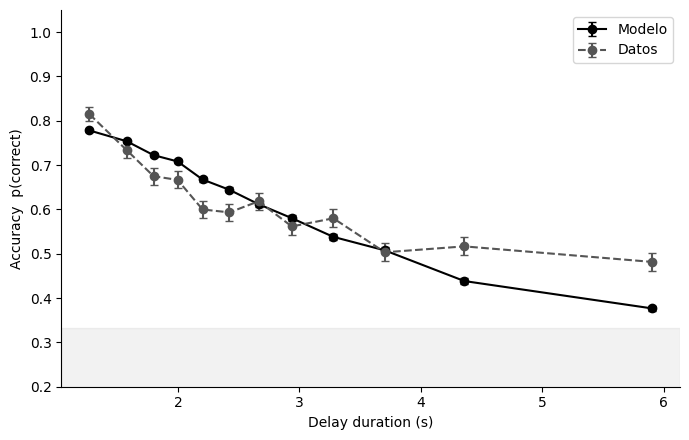

In [ ]:
plot_model_vs_data_by_var(subject='A89', n_bins=12, M=300, var_x='delay_duration', show_stim_markers=False)

## Bining by 2 variables

In [ ]:
x_var = 'delay_duration'   #'offset' 'stim_duration' o 'delay_duration'
t4_colors = delay_colors
n_t4_bins = 4
n_x_bins = 6
subject = 'A89'

df_subj = df[(df['subject']==subject)].copy()
df_subj['t4_bin'], t4_edges = pd.qcut(df_subj['timepoint_4'],
                                      q=n_t4_bins, retbins=True, duplicates='drop')

t4_centros = (df_subj.groupby('t4_bin', observed=True)['timepoint_4']
              .median().rename('t4_center').reset_index()
              .sort_values('t4_center'))
t4_order   = list(t4_centros['t4_bin'])
t4_centers = t4_centros['t4_center'].to_numpy()

plt.figure(figsize=(8,5))

for i, t4_cat in enumerate(t4_order):
    color = 'red'
    group = df_subj[df_subj['t4_bin'] == t4_cat].copy()
    if len(group) == 0:
        continue

    group['x_bin'], x_edges = pd.qcut(group[x_var], n_x_bins, retbins=True, duplicates='drop')

    x_centros = (group.groupby('x_bin', observed=True)[x_var]
                 .median().rename('x_center').reset_index()
                 .sort_values('x_center'))
    x_centers = x_centros['x_center'].to_numpy()
    x_order   = list(x_centros['x_bin'])

    y_data, y_data_sem = [], []
    y_model, y_model_sem = [], []

    for cat in x_order:
        bin_trials = group[group['x_bin'] == cat]

        if len(bin_trials) > SUBSAMPLE_PER_BIN:
            parts = []
            for s in ['L','C','R']:
                g = bin_trials[bin_trials['x_c']==s]
                k = min(len(g), SUBSAMPLE_PER_BIN//3)
                parts.append(g.sample(k, random_state=0))
            bin_trials = pd.concat(parts, axis=0)

        acc = bin_trials['correct_bool'].to_numpy(dtype=float)
        y_data.append(float(acc.mean()) if len(acc)>0 else np.nan)
        if len(acc)>1:
            p = float(acc.mean()); n = len(acc)
            y_data_sem.append(np.sqrt(p*(1-p)/n))
        else:
            y_data_sem.append(0.0)

        m, s = model_mean_for_trials(bin_trials)
        y_model.append(m); y_model_sem.append(s)

    y_data  = np.asarray(y_data, float)
    y_data_sem  = np.asarray(y_data_sem, float)
    y_model = np.asarray(y_model, float)
    y_model_sem = np.asarray(y_model_sem, float)


    plt.errorbar(x_centers, y_model, yerr=y_model_sem, fmt='-o',
                 color=color, capsize=3, markersize=5,
                 label=f'T4 bin {t4_edges[i]:.2f}-{t4_edges[i+1]:.2f}')

    plt.errorbar(x_centers, y_data, yerr=y_data_sem, fmt='--o',
                 color=color, capsize=3, markersize=5,
                 label=f'Data')

# Decoración global
plt.axhspan(0, 1/3, color='gray', alpha=0.1, zorder=0)
xlabel_map = {'offset':'Stimulus offset (s)',
              'stim_duration':'Stimulus duration (s)',
              'delay_duration':'Delay duration (s)'}
plt.xlabel(xlabel_map.get(x_var, x_var))
plt.ylabel('Accuracy  p(correct)')
plt.ylim(0.2, 1.05)
sns.despine()
plt.legend(ncol=2)
plt.tight_layout()
plt.savefig(f'{x_var}_{subject}.png', dpi=200)
plt.show()

KeyboardInterrupt: 

<Figure size 800x500 with 0 Axes>

In [ ]:
n_t4_bins = 3
n_x_bins  = 7
SUBSAMPLE_PER_BIN = 600
x_var = 'delay_duration'   #'offset' 'stim_duration' o 'delay_duration' si quieres

df_subj = df[(df['subject']==subject)].copy()

# ========= Binning externo por T4 (timepoint_4) =========
df_subj['t4_bin'], t4_edges = pd.qcut(df_subj['timepoint_4'],
                                      q=n_t4_bins, retbins=True, duplicates='drop')

# Ordenar los estratos por su mediana de T4 (etiquetas & centros)
t4_centros = (df_subj.groupby('t4_bin', observed=True)['timepoint_4']
              .median().rename('t4_center').reset_index()
              .sort_values('t4_center'))
t4_order   = list(t4_centros['t4_bin'])
t4_centers = t4_centros['t4_center'].to_numpy()

plt.figure(figsize=(8,5))

# ========= Recorre cada estrato de T4 =========
for i, t4_cat in enumerate(t4_order):
    color = t4_colors[i]
    group = df_subj[df_subj['t4_bin'] == t4_cat].copy()
    if len(group) == 0:
        continue

    # ----- Binning interno en el eje X (offset por defecto) -----
    # Usamos quantiles dentro del estrato para que haya población en cada bin
    group['x_bin'], x_edges = pd.qcut(group[x_var], n_x_bins, retbins=True, duplicates='drop')

    # Centros de X ordenados
    x_centros = (group.groupby('x_bin', observed=True)[x_var]
                 .median().rename('x_center').reset_index()
                 .sort_values('x_center'))
    x_centers = x_centros['x_center'].to_numpy()
    x_order   = list(x_centros['x_bin'])

    y_data, y_data_sem = [], []
    y_model, y_model_sem = [], []

    for cat in x_order:
        bin_trials = group[group['x_bin'] == cat]

        # Submuestreo balanceado por lado (opcional)
        if len(bin_trials) > SUBSAMPLE_PER_BIN:
            parts = []
            for s in ['L','C','R']:
                g = bin_trials[bin_trials['x_c']==s]
                k = min(len(g), SUBSAMPLE_PER_BIN//3)
                parts.append(g.sample(k, random_state=0))
            bin_trials = pd.concat(parts, axis=0)

        # Datos
        acc = bin_trials['correct_bool'].to_numpy(dtype=float)
        y_data.append(float(acc.mean()) if len(acc)>0 else np.nan)
        # SEM binomial de datos
        if len(acc)>1:
            p = float(acc.mean()); n = len(acc)
            y_data_sem.append(np.sqrt(p*(1-p)/n))
        else:
            y_data_sem.append(0.0)

        # Modelo (usa tu helper)
        m, s = model_mean_for_trials(bin_trials)
        y_model.append(m); y_model_sem.append(s)

    y_data  = np.asarray(y_data, float)
    y_data_sem  = np.asarray(y_data_sem, float)
    y_model = np.asarray(y_model, float)
    y_model_sem = np.asarray(y_model_sem, float)

    # ----- Dibujar dos líneas por estrato (mismo color) -----
    # Modelo (línea sólida)
    plt.errorbar(x_centers, y_model, yerr=y_model_sem, fmt='-o',
                 color=color, capsize=3, markersize=5,
                 label=f'T4 bin {t4_edges[i]:.2f}-{t4_edges[i+1]:.2f}')

    # Datos (misma X, color y línea discontinua)
    plt.errorbar(x_centers, y_data, yerr=y_data_sem, fmt='--o',
                 color=color, capsize=3, markersize=5,
                 label=f'Data')

# Decoración global
plt.axhspan(0, 1/3, color='gray', alpha=0.1, zorder=0)
xlabel_map = {'offset':'Stimulus offset (s)',
              'stim_duration':'Stimulus duration (s)',
              'delay_duration':'Delay duration (s)'}
plt.xlabel(xlabel_map.get(x_var, x_var))
plt.ylabel('Accuracy  p(correct)')
plt.ylim(0.2, 1.05)
import seaborn as sns; sns.despine()
plt.legend(ncol=2)
plt.tight_layout()
plt.savefig(f'{x_var}_{subject}.png', dpi=200)
plt.show()

In [ ]:
def plot_accuracy_binned(df,subject='A92',outer_var='timepoint_4',x_var='delay_duration',n_t4_bins=3,n_x_bins=7,SUBSAMPLE_PER_BIN=600):

    df_subj = df[
        (df['subject']==subject) &
        (df['onset'] == 0) &
        (df['timepoint_4']< np.percentile(df['timepoint_4'], 95))
    ].copy()
    
    df_subj['outer_bin'], outer_edges = pd.qcut(
        df_subj[outer_var], q=n_t4_bins, retbins=True, duplicates='drop'
    )

    outer_centros = (df_subj.groupby('outer_bin', observed=True)[outer_var]
                     .median().rename('outer_center').reset_index()
                     .sort_values('outer_center'))
    outer_order   = list(outer_centros['outer_bin'])

    plt.figure(figsize=(8,5))

    for i, obin in enumerate(outer_order):
        color = t4_colors[i % len(t4_colors)]
        group = df_subj[df_subj['outer_bin'] == obin].copy()
        if len(group) == 0:
            continue

        group['x_bin'], x_edges = pd.qcut(group[x_var], n_x_bins, retbins=True, duplicates='drop')

        x_centros = (group.groupby('x_bin', observed=True)[x_var]
                     .median().rename('x_center').reset_index()
                     .sort_values('x_center'))
        x_centers = x_centros['x_center'].to_numpy()
        x_order   = list(x_centros['x_bin'])

        y_data, y_data_sem = [], []
        y_model, y_model_sem = [], []

        for cat in x_order:
            bin_trials = group[group['x_bin'] == cat]

            if len(bin_trials) > SUBSAMPLE_PER_BIN:
                parts = []
                for s in ['L','C','R']:
                    g = bin_trials[bin_trials['x_c']==s]
                    k = min(len(g), SUBSAMPLE_PER_BIN//3)
                    parts.append(g.sample(k, random_state=0))
                bin_trials = pd.concat(parts, axis=0)

            acc = bin_trials['correct_bool'].to_numpy(dtype=float)
            y_data.append(float(acc.mean()) if len(acc)>0 else np.nan)
            if len(acc)>1:
                p = float(acc.mean()); n = len(acc)
                y_data_sem.append(np.sqrt(p*(1-p)/n))
            else:
                y_data_sem.append(0.0)

            m, s = model_mean_for_trials(bin_trials)
            y_model.append(m); y_model_sem.append(s)

        y_data       = np.asarray(y_data, float)
        y_data_sem   = np.asarray(y_data_sem, float)
        y_model      = np.asarray(y_model, float)
        y_model_sem  = np.asarray(y_model_sem, float)

        plt.errorbar(
            x_centers, y_model, yerr=y_model_sem, fmt='-o',
            color=color, capsize=3, markersize=5,
            label=f'{outer_var} bin {outer_edges[i]:.2f}-{outer_edges[i+1]:.2f}'
        )

        plt.errorbar(
            x_centers, y_data, yerr=y_data_sem, fmt='--o',
            color=color, capsize=3, markersize=5,
            label='Data'
        )

    plt.axhspan(0, 1/3, color='gray', alpha=0.1, zorder=0)
    xlabel_map = {'offset':'Stimulus offset (s)',
                  'stim_duration':'Stimulus duration (s)',
                  'delay_duration':'Delay duration (s)'}
    plt.xlabel(xlabel_map.get(x_var, x_var))
    plt.ylabel('Accuracy  p(correct)')
    plt.ylim(0.2, 1.05)
    sns.despine()
    plt.legend(ncol=2)
    plt.tight_layout()
    plt.savefig(f'{x_var}_{subject}.png', dpi=200)
    plt.show()



subject = 'A89'
x_var = 'delay_duration'   #'offset' 'stim_duration' o 'delay_duration'
n_t4_bins = 3
n_x_bins  = 7
t4_colors = list(delay_colors.values())
plot_accuracy_binned(df, subject=subject, outer_var='offset', x_var='delay_duration', n_t4_bins=n_t4_bins, n_x_bins=n_x_bins, SUBSAMPLE_PER_BIN=SUBSAMPLE_PER_BIN)

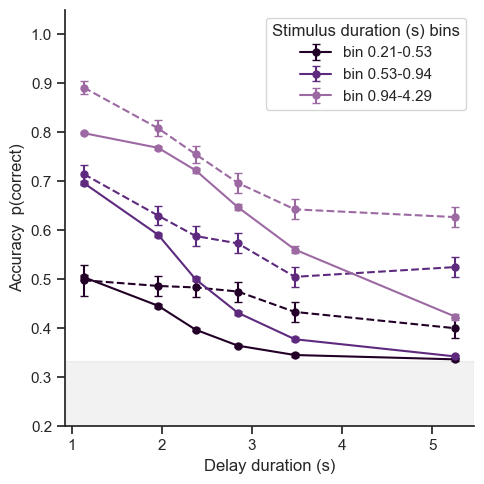

In [ ]:
M = 200
var_names = {'stim_duration':'Stimulus duration (s)',
             'delay_duration':'Delay duration (s)',
             'offset':'Stimulus offset (s)'}


def plot_accuracy_binned(df,subject='A92',outer_var='timepoint_4',x_var='delay_duration',n_t4_bins=3,n_x_bins=7,SUBSAMPLE_PER_BIN=600):

    df_subj = df[
        (df['subject']==subject) &
        (df['onset'] == 0) ].copy()

    df_subj['outer_bin'], outer_edges = pd.qcut(
        df_subj[outer_var], q=n_t4_bins, retbins=True, duplicates='drop'
    )
    outer_centros = (df_subj.groupby('outer_bin', observed=True)[outer_var].median().rename('outer_center').reset_index().sort_values('outer_center'))
    outer_order   = list(outer_centros['outer_bin'])


    _, x_edges = pd.qcut(df_subj[x_var], n_x_bins, retbins=True, duplicates='drop')
    x_centers = 0.5*(x_edges[:-1] + x_edges[1:]) 

    plt.figure(figsize=(5,5))

    for i, obin in enumerate(outer_order):
        color = t4_colors[i % len(t4_colors)]
        group = df_subj[df_subj['outer_bin'] == obin].copy()

        group['x_bin'] = pd.cut(group[x_var], bins=x_edges, include_lowest=True)

        y_data, y_data_sem = [], []
        y_model, y_model_sem = [], []

        cats = group['x_bin'].cat.categories

        for j in range(len(x_centers)):
            if j >= len(cats):
                y_data.append(np.nan); y_data_sem.append(0.0)
                y_model.append(np.nan); y_model_sem.append(0.0)
                continue

            this_cat = cats[j]
            bin_trials = group[group['x_bin'] == this_cat]

            if len(bin_trials) > SUBSAMPLE_PER_BIN:
                parts = []
                for s in ['L','C','R']:
                    g = bin_trials[bin_trials['x_c']==s]
                    k = min(len(g), SUBSAMPLE_PER_BIN//3)
                    parts.append(g.sample(k, random_state=0))
                if len(parts)>0:
                    bin_trials = pd.concat(parts, axis=0)

            acc = bin_trials['correct_bool'].to_numpy(dtype=float)
            if len(acc)>0:
                p = float(acc.mean()); n = len(acc)
                y_data.append(p)
                y_data_sem.append(np.sqrt(p*(1-p)/n) if n>1 else 0.0)
            else:
                y_data.append(np.nan); y_data_sem.append(0.0)

            m, s = model_mean_for_trials(bin_trials)
            y_model.append(m); y_model_sem.append(s)

        y_data       = np.asarray(y_data, float)
        y_data_sem   = np.asarray(y_data_sem, float)
        y_model      = np.asarray(y_model, float)
        y_model_sem  = np.asarray(y_model_sem, float)

        plt.errorbar(
            x_centers, y_model, yerr=y_model_sem, fmt='-o',
            color=color, capsize=3, markersize=5,
            label=f'bin {outer_edges[i]:.2f}-{outer_edges[i+1]:.2f}'
        )
        plt.errorbar(
            x_centers, y_data, yerr=y_data_sem, fmt='--o',
            color=color, capsize=3, markersize=5,
        )

    plt.axhspan(0, 1/3, color='gray', alpha=0.1, zorder=0)
    xlabel_map = {'offset':'Stimulus offset (s)',
                  'stim_duration':'Stimulus duration (s)',
                  'delay_duration':'Delay duration (s)'}
    plt.xlabel(xlabel_map.get(x_var, x_var))
    plt.ylabel('Accuracy  p(correct)')
    plt.ylim(0.2, 1.05)
    sns.despine()
    plt.legend(ncol=2)
    plt.tight_layout()
    plt.savefig(f'{x_var}_{subject}.png', dpi=200)
    plt.legend(title=f'{var_names[outer_var]} bins')
    plt.xlabel(f'Delay duration (s)')
    sns.despine()
    sns.set()
    sns.set_style('white')
    sns.set_style('ticks')
    plt.show()

t4_colors = list(delay_colors.values())
to_plot = df.copy()
trial_length_p95 = np.percentile(df['timepoint_4'], 95)
to_plot = df[df['timepoint_4'] <= trial_length_p95].copy()
to_plot = to_plot[to_plot['ttype_c'] != 'VG']
plot_accuracy_binned(
    to_plot, subject='A89',
    outer_var='stim_duration',
    x_var='delay_duration',
    n_t4_bins=3, n_x_bins=6, SUBSAMPLE_PER_BIN=600
)